# Trabajo Práctico 1: Regresión Lineal
**Materia:** I302 - Aprendizaje Automático y Aprendizaje Profundo  
**Alumno:** Luis Augusto Embon Strizzi  
**Fecha:** 27 de Marzo de 2026

## 1. Análisis Exploratorio de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

### 1.1) Exploración del Dataset

In [2]:
df = pd.read_csv("../data/raw/casas_dev.csv")
print(df.sample(5))

            precio  tipo        Área  metros_cubiertos unidades  ambientes  \
667   50116.745075  casa  224.692921        140.930951       m2         10   
1206   6061.096735    ph  133.089856        118.025286       m2         10   
873    1732.493340    ph  134.453274        113.660235       m2          9   
1186  26115.554543  casa  241.649873        116.259611       m2          9   
1395  19601.217775  casa  221.127062        100.603463       m2          6   

      pisos  pileta        lat        lon       edad  
667     3.0    True -34.722901 -58.263464  44.195421  
1206    2.0   False -34.716129 -58.252742  16.365375  
873     1.0   False -34.804235 -58.222961  20.289859  
1186    3.0   False -34.699585 -58.303809  74.213355  
1395    2.0   False -34.769744 -58.266737  34.216393  


In [3]:
print(df.describe(include="all"))

               precio   tipo         Área  metros_cubiertos unidades  \
count     1545.000000   1600  1600.000000       1600.000000     1600   
unique            NaN      3          NaN               NaN        2   
top               NaN  depto          NaN               NaN       m2   
freq              NaN    852          NaN               NaN      907   
mean     93343.692526    NaN   441.793691        389.079682      NaN   
std      96555.245985    NaN   312.059318        316.426294      NaN   
min          0.000000    NaN    54.214835         52.612659      NaN   
25%      15425.306495    NaN   213.297952        114.295562      NaN   
50%      43042.341770    NaN   251.370981        166.433788      NaN   
75%     169055.639631    NaN   734.053341        712.503363      NaN   
max     769962.673560    NaN  2475.718589       1553.965444      NaN   

          ambientes       pisos pileta          lat          lon         edad  
count   1600.000000  748.000000   1600  1600.000000  16

In [4]:
print(df.isnull())

      precio   tipo   Área  metros_cubiertos  unidades  ambientes  pisos  \
0      False  False  False             False     False      False   True   
1      False  False  False             False     False      False  False   
2       True  False  False             False     False      False   True   
3      False  False  False             False     False      False   True   
4      False  False  False             False     False      False  False   
...      ...    ...    ...               ...       ...        ...    ...   
1595   False  False  False             False     False      False   True   
1596   False  False  False             False     False      False  False   
1597   False  False  False             False     False      False   True   
1598   False  False  False             False     False      False  False   
1599   False  False  False             False     False      False   True   

      pileta    lat    lon   edad  
0      False  False  False   True  
1      False  F

In [5]:
print(df.isnull().sum())

precio               55
tipo                  0
Área                  0
metros_cubiertos      0
unidades              0
ambientes             0
pisos               852
pileta                0
lat                   0
lon                   0
edad                149
dtype: int64


In [6]:
print(df.groupby('unidades')[['Área', 'metros_cubiertos']].mean().round(2))

            Área  metros_cubiertos
unidades                          
m2        190.23            120.96
sqft      771.03            740.00


In [7]:

print(df[df['precio'] <= 0])

      precio   tipo        Área  metros_cubiertos unidades  ambientes  pisos  \
38       0.0   casa  228.691782        144.378650       m2          6    2.0   
43       0.0   casa  232.323738        123.652062       m2         10    3.0   
71       0.0  depto  826.326231        795.794650     sqft          4    NaN   
102      0.0  depto   68.203506         65.069758       m2         10    NaN   
142      0.0  depto  702.900945        701.232643     sqft          7    NaN   
180      0.0   casa  190.693267        146.937779       m2          8    3.0   
198      0.0   casa  250.811501        142.795660       m2         10    3.0   
236      0.0     ph  134.219848        107.652767       m2          6    1.0   
306      0.0   casa  205.362880        110.480309       m2          4    1.0   
307      0.0   casa  260.131058        205.804440       m2         10    3.0   
330      0.0   casa  259.383918        155.667532       m2         10    3.0   
365      0.0  depto  761.958764        7

In [8]:
print(df[df['metros_cubiertos'] <= 0])

Empty DataFrame
Columns: [precio, tipo, Área, metros_cubiertos, unidades, ambientes, pisos, pileta, lat, lon, edad]
Index: []


In [9]:
print(df[df['metros_cubiertos'] > df['Área']])

Empty DataFrame
Columns: [precio, tipo, Área, metros_cubiertos, unidades, ambientes, pisos, pileta, lat, lon, edad]
Index: []


In [10]:
print(df[~(df['edad'] >= 0) & (df['edad'] <= 120)])

Empty DataFrame
Columns: [precio, tipo, Área, metros_cubiertos, unidades, ambientes, pisos, pileta, lat, lon, edad]
Index: []


In [11]:
print(df[(df['tipo'] == 'depto') & (df['pisos'].isna())])

             precio   tipo        Área  metros_cubiertos unidades  ambientes  \
0     159001.587058  depto  721.976728        703.066245     sqft          5   
2               NaN  depto   73.856399         72.887849       m2          4   
3     135972.861876  depto  776.709623        747.693158     sqft          5   
7     179452.480343  depto  851.461518        830.991007     sqft          2   
9     221054.994134  depto  830.968041        821.480555     sqft          5   
...             ...    ...         ...               ...      ...        ...   
1593  162749.789067  depto  852.771314        814.847686     sqft          7   
1594  216319.401607  depto  742.705566        713.828490     sqft          9   
1595  161092.730185  depto  780.737575        777.125532     sqft          5   
1597       0.000000  depto  800.370634        761.852744     sqft          7   
1599  259689.483004  depto  666.438187        642.692495     sqft          2   

      pisos  pileta        lat        l

In [12]:
print(df['lat'])
print(df['lon'])

0       40.738155
1      -34.710794
2      -34.704461
3       40.847320
4      -34.777778
          ...    
1595    40.777561
1596   -34.701040
1597    40.734165
1598   -34.766141
1599    40.784184
Name: lat, Length: 1600, dtype: float64
0      -73.992277
1      -58.280446
2      -58.256815
3      -74.011712
4      -58.255182
          ...    
1595   -73.928190
1596   -58.216300
1597   -73.978716
1598   -58.290428
1599   -74.016680
Name: lon, Length: 1600, dtype: float64


#### Análisis y extracción de conclusiones
Tras una inspección inicial del dataset casas_dev.csv, se confirma que el conjunto de datos presenta diversas inconsistencias que requieren una etapa de limpieza antes de proceder al modelado.

Para comprender mejor la estructura de los datos, se imprimió una muestra aleatoria del dataset utilizando df.sample(5), lo que permitió observar la disposición de las variables y detectar problemas preliminares en los registros.

A partir del análisis estadístico (describe) y la detección de valores nulos (isnull), se identificaron varios puntos críticos. En primer lugar, la variable objetivo precio presenta 55 valores faltantes (NaN) y 57 registros con valor 0.0. Un precio de 0 no representa una transacción real: ninguna propiedad se vende por cero dólares, por lo que estos valores corresponden casi con seguridad a errores de carga o a un placeholder utilizado para señalar información faltante. Se decidió eliminar estas filas en lugar de imputarlas por una razón específica del rol que cumple esta variable: el precio es el target, es decir, la señal que supervisa el aprendizaje. Si imputáramos el target (por ejemplo, con la mediana), estaríamos fabricando las etiquetas que el modelo luego intenta reproducir: el modelo aprendería en parte de valores inventados por nosotros y las métricas quedarían contaminadas por esos valores sintéticos. A diferencia de lo que ocurre al imputar una feature (donde el dato imputado es una entrada más entre muchas, y el target real sigue corrigiendo al modelo durante el entrenamiento), una fila sin target no aporta información de supervisión genuina. Considerando además que las filas afectadas son una fracción pequeña del dataset (112 sobre 1600), eliminarlas es la opción de menor riesgo y menor costo.

En cuanto a la variable pisos, se observa que contiene la mayor cantidad de valores faltantes (852). A pesar de esto, se decidió conservarla por su potencial predictivo. Para tratar los valores nulos, se podría optar por una imputación simple utilizando la moda de la variable. Esta decisión permite mantener la coherencia de una variable discreta y evita introducir valores irreales.

Por otro lado, la variable edad también presenta valores faltantes (149 en total). En este caso, se podría imputar utilizando la mediana del conjunto de entrenamiento. Esta elección se debe a que la mediana es una medida robusta frente a valores extremos y permite representar adecuadamente una propiedad "típica" sin distorsionar la distribución.

Por otro lado, las variables de geolocalización (lat, lon) no presentan valores nulos, pero sí muestran una desviación estándar elevada, especialmente en la latitud (37.43). Esto confirma la coexistencia de dos regiones geográficas claramente diferenciadas (Argentina y Estados Unidos). En consecuencia, estas variables no deberían utilizarse directamente en un modelo lineal sin algún tipo de transformación. Una alternativa natural es generar una variable categórica que identifique el país, para capturar esta heterogeneidad. Luego, en la parte de feature engineering se trabaja más en detalle con estas variables.

Otro problema relevante es la inconsistencia de unidades en las variables relacionadas con superficie (unidades, Área, metros_cubiertos). El dataset combina propiedades de Estados Unidos, medidas en sqft (pies cuadrados), con propiedades de Argentina, medidas en m². La unificación aquí no es opcional ni depende de lo que muestren los gráficos: en una regresión lineal cada columna recibe un único coeficiente, por lo que debe medir una única magnitud en una única escala. Si una misma columna mezcla metros y pies cuadrados, ese coeficiente no tiene interpretación posible. Por lo tanto, es necesario convertir todas las observaciones a una misma unidad antes de entrenar.

Finalmente, el análisis de los estadísticos descriptivos muestra que la distribución del precio es altamente asimétrica. El valor máximo alcanza los 769,962 USD, mientras que el mínimo es 0, y el 75% de las propiedades se encuentra por debajo de los 169,000 USD. Esto indica la presencia de algunos valores muy altos que se alejan del resto. Frente a este tipo de asimetría, una técnica habitual es transformar el target (por ejemplo, con un logaritmo) para comprimir la cola derecha de la distribución. Dejamos planteada esta transformación como un experimento a realizar: en la sección 4.2, junto con los modelos con feature engineering, se entrena una variante que predice log(precio) y se reportan sus resultados.

### 1.2) Visualización de variables

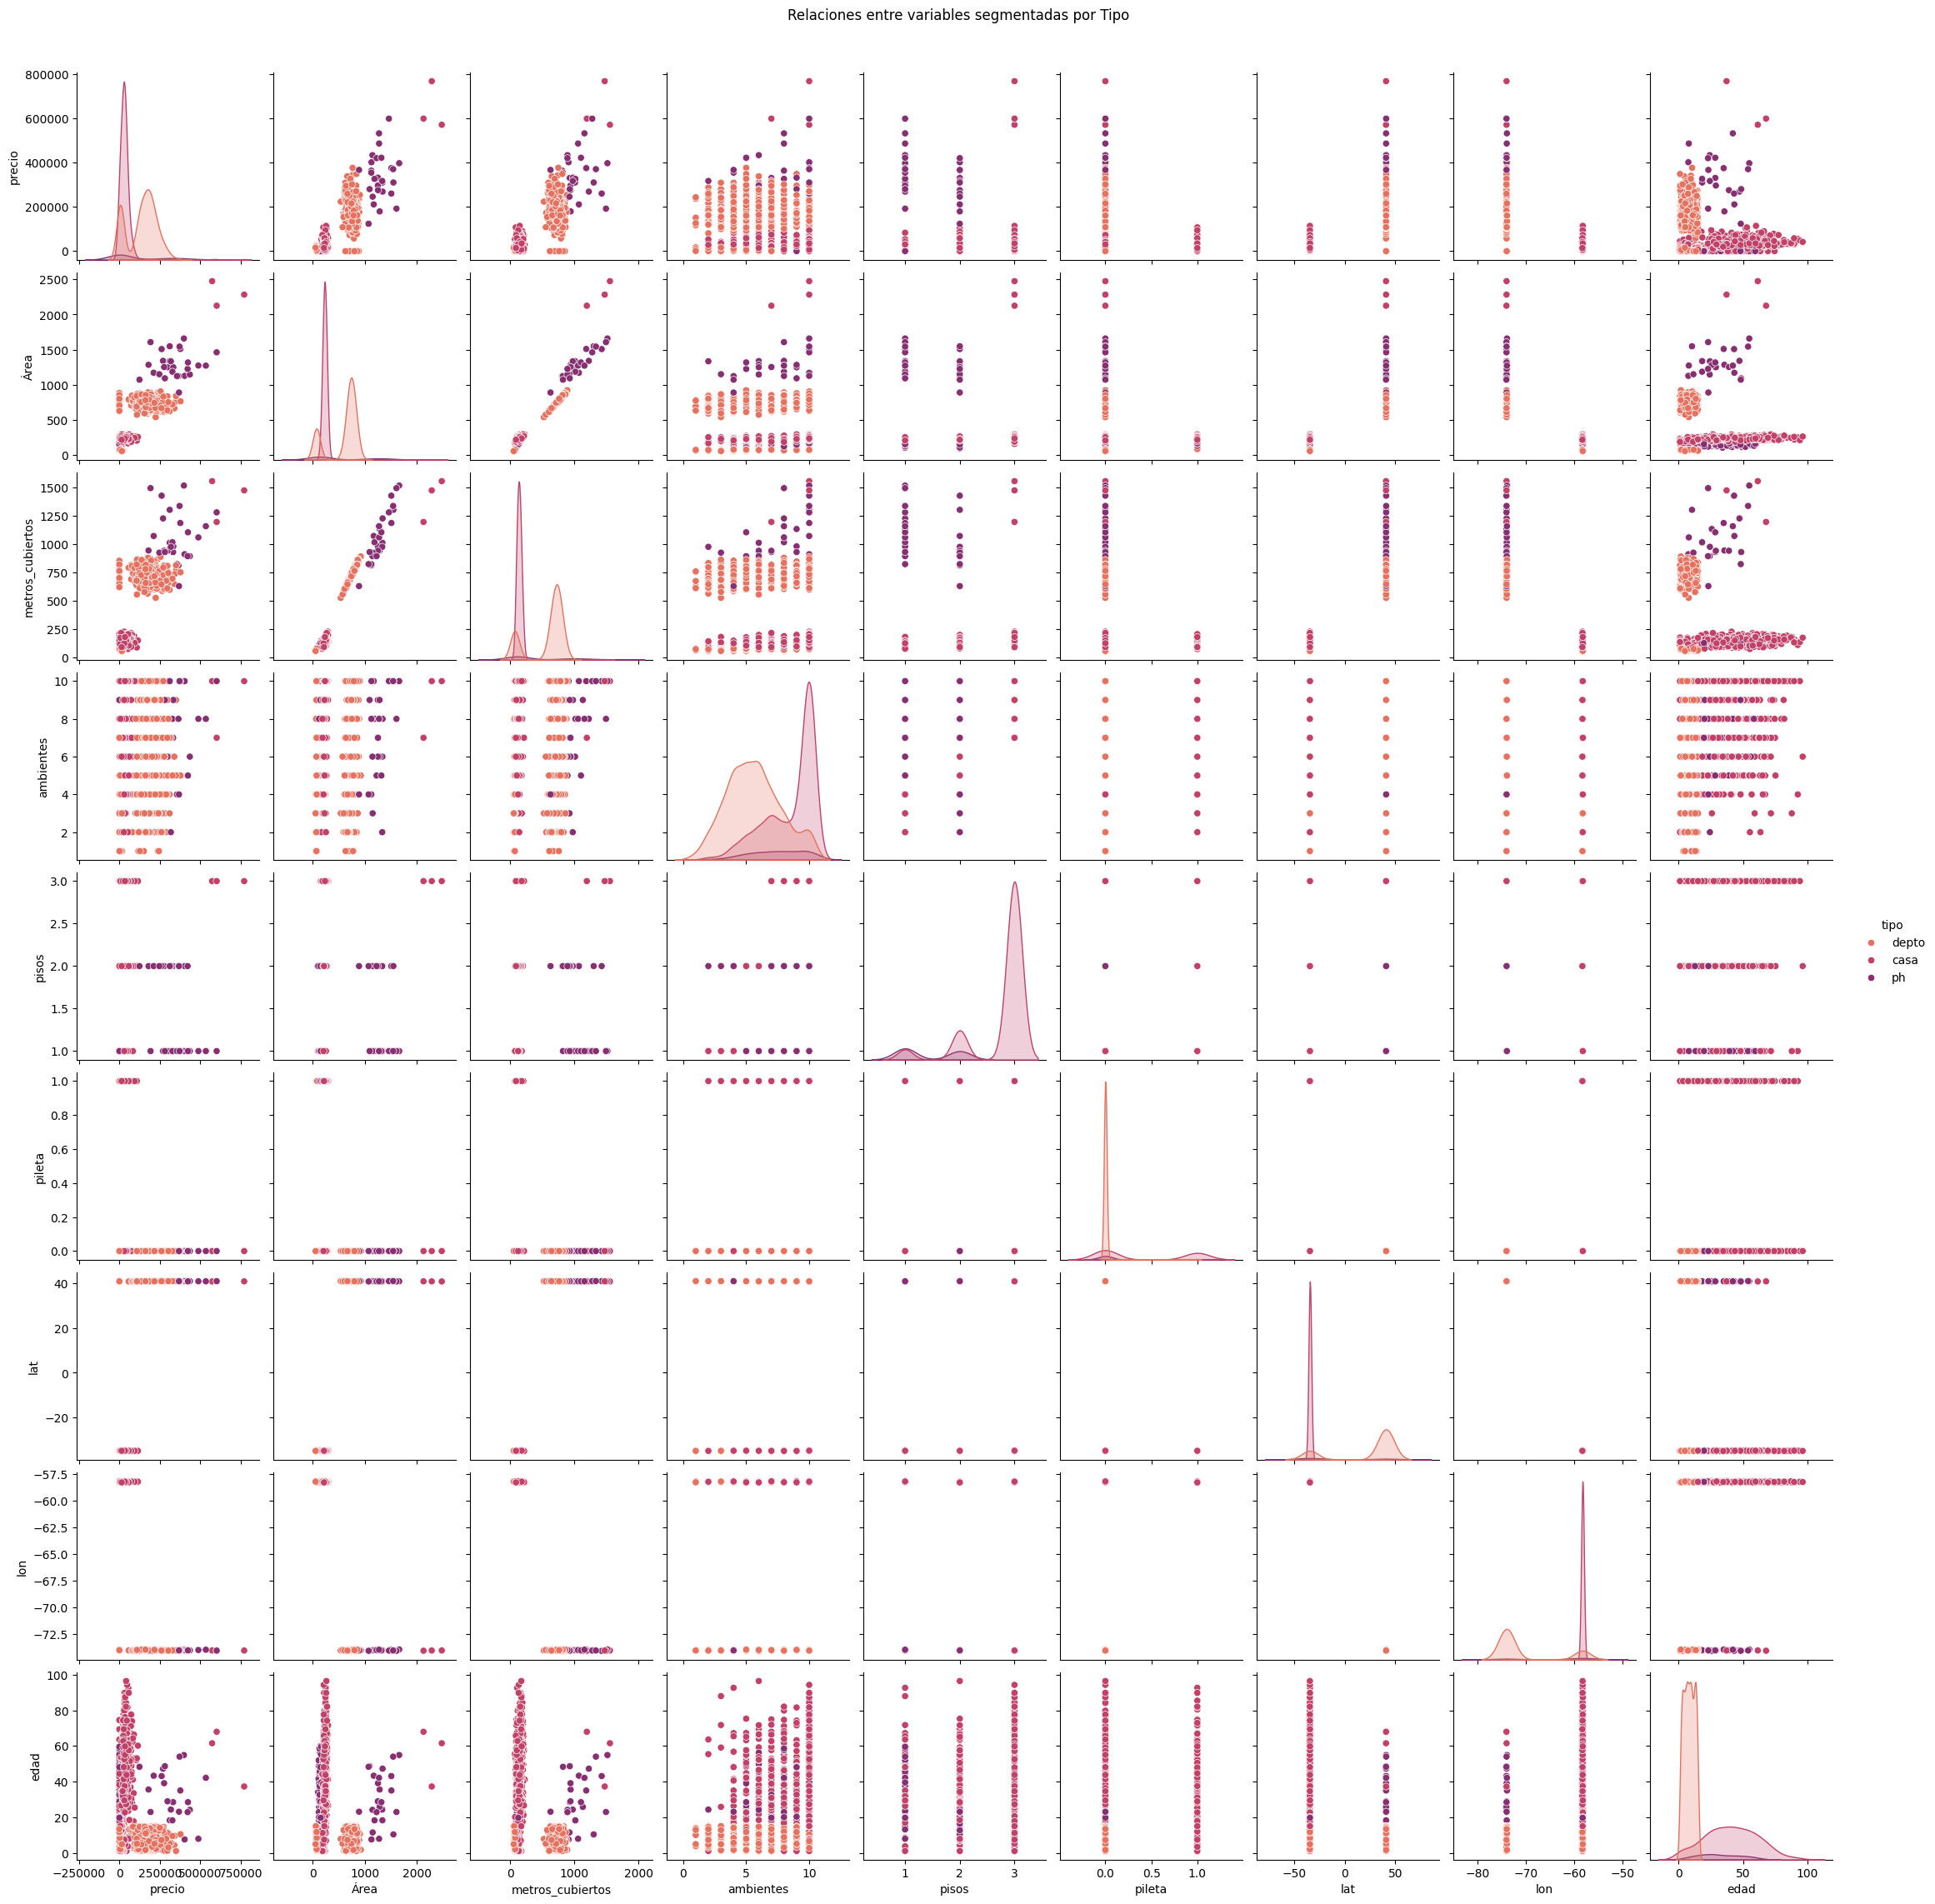

In [13]:
sns.pairplot(df[['precio', 'Área', 'metros_cubiertos','unidades', 'ambientes','pisos','pileta','lat','lon', 'edad', 'tipo']], 
             hue='tipo', diag_kind='kde', palette="flare")
plt.suptitle("Relaciones entre variables segmentadas por Tipo", y=1.02)
plt.show()

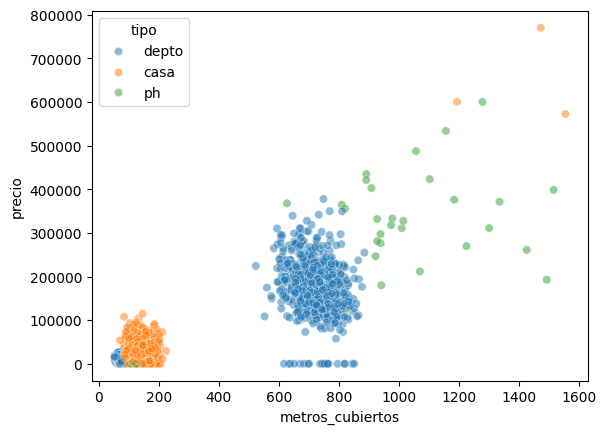

In [14]:
sns.scatterplot(data=df, x='metros_cubiertos', y='precio', hue='tipo', alpha=0.5)
plt.show()

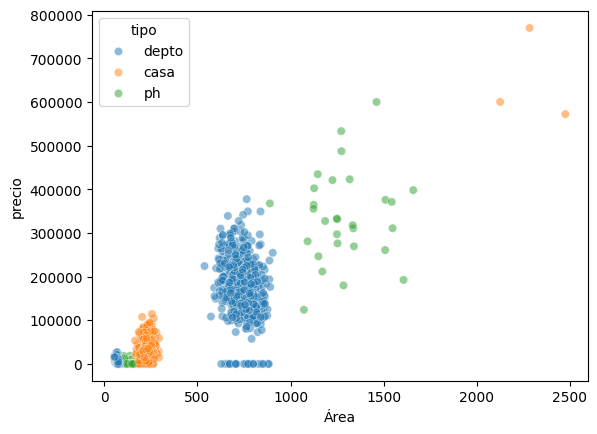

In [15]:
sns.scatterplot(data=df, x='Área', y='precio', hue='tipo', alpha=0.5)
plt.show()

Al analizar la matriz de gráficos de dispersión y densidad, se obtienen conclusiones que validan nuestras decisiones de preprocesamiento y exponen la naturaleza del dataset:

En primer lugar, las distribuciones de latitud (lat) y longitud (lon) muestran una clara bimodalidad en los gráficos de la diagonal. La presencia de dos picos bien definidos confirma que el dataset no es homogéneo; está compuesto por dos poblaciones geográficamente separadas: Argentina (Lat < 0) y Estados Unidos (Lat > 0). 
Luego, al observar la relación entre superficie (Área, metros_cubiertos) y el precio, se identifica una correlación lineal positiva clara. Sin embargo, los puntos se agrupan en dos "nubes" desplazadas. Este patrón visual confirma la coexistencia de distintas unidades (m² y sqft). Las propiedades de EE. UU. ocupan valores numéricos mucho más altos en el eje horizontal. Vale aclarar el rol de esta observación: la separación de las nubes no es la justificación para unificar las unidades (la unificación es necesaria por definición, se vea o no en un gráfico, porque una misma columna no puede mezclar escalas distintas), sino la evidencia que permite detectar el problema y confirmar qué registros están expresados en cada unidad.
Además, podemos mencionar que la inclusión de la variable tipo como segmentación por color revela algunos patrones que se contrastan:

- Con respecto a la distribución de área, las casas se encuentran en ambos extremos: un grupo de superficie reducida (Argentina) y un grupo de gran escala (EE. UU.). Los departamentos, en cambio, se concentran casi exclusivamente en el cluster intermedio correspondiente a EE. UU.

- Con respecto a la información faltante en pisos podemos ver que, mientras que las casas muestran una distribución escalonada clara (franjas en 1, 2 y 3 pisos), el gráfico para departamentos aparece prácticamente vacío. Esto confirma que la gran mayoría de los departamentos no cuentan con este dato, validando la necesidad de una estrategia de imputación.

- Si miramos si contienen pileta o no, vemos que los puntos de las casas aparecen distribuidos entre ambos estados (con y sin pileta), mientras que departamentos y PHs se concentran masivamente en el valor 0.0, señalando a la pileta como un predictor de alto valor para el segmento de casas.

- Se detecta un aumento en la dispersión de los precios a medida que crece el tamaño de las propiedades. Esta "nube" más amplia en los valores altos indica que el error del modelo probablemente será mayor en propiedades de alta gama.

- Se observa que las propiedades más nuevas (cercanas a 0 años) presentan la mayor variabilidad de precios. A medida que aumenta la antigüedad, los valores tienden a estabilizarse y concentrarse en rangos más bajos. Esto indica que, en promedio, las propiedades más antiguas suelen valer menos.

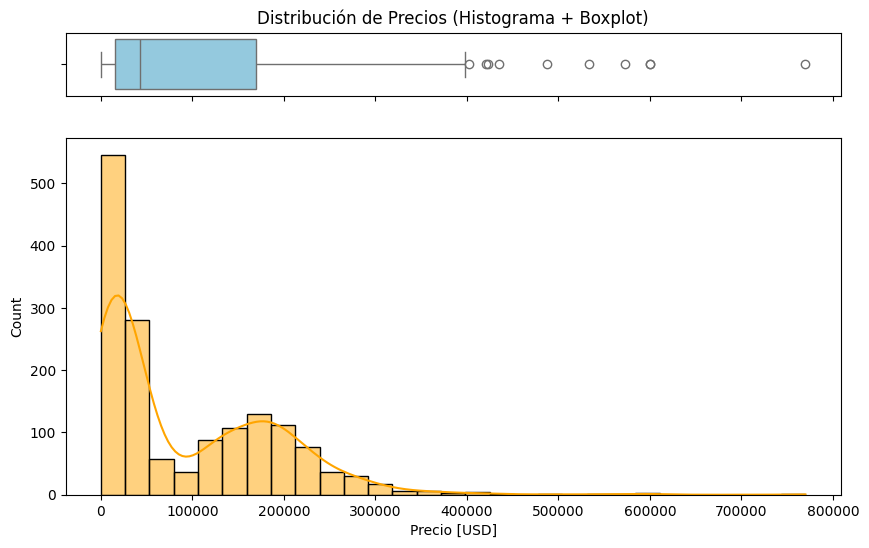

In [16]:
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10,6))
sns.boxplot(x=df["precio"], ax=ax_box, color="skyblue")
sns.histplot(x=df["precio"], ax=ax_hist, kde=True, color="orange")
ax_box.set_title('Distribución de Precios (Histograma + Boxplot)')
ax_hist.set_xlabel("Precio [USD]")
plt.show()

El histograma combinado con el boxplot permite visualizar la estructura del precio que discutimos anteriormente.
Primeramente, se observa una altísima concentración de propiedades en el rango de 0 a 50,000 USD (el pico más alto del histograma). Luego, el boxplot superior muestra una gran cantidad de puntos más allá de los 400,000 USD, llegando casi a los 800,000 USD. Finalmente, se detecta una columna significativa en el valor exacto de 0, lo que confirma errores de carga de datos que deben ser eliminados para no sesgar el promedio del modelo.

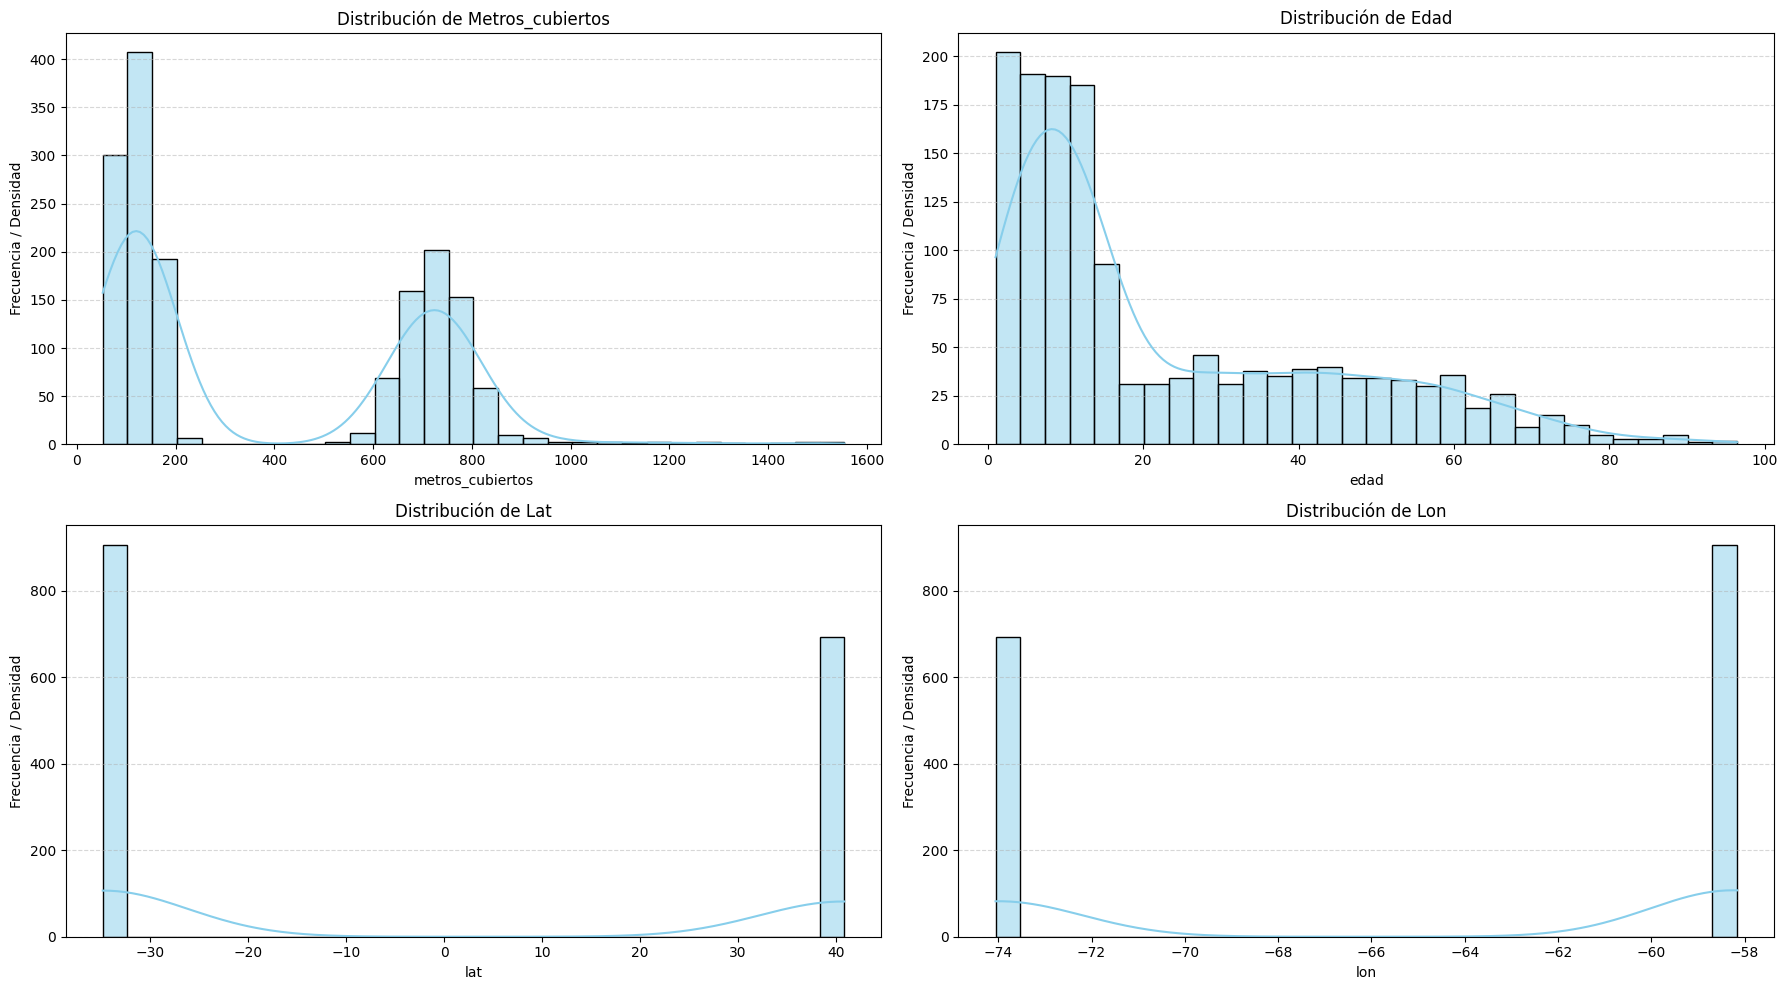

In [17]:

variables_numericas = ['metros_cubiertos', 'edad', 'lat', 'lon']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(variables_numericas):
    sns.histplot(df[var], kde=True, ax=axes[i], color='skyblue', edgecolor='black', bins=30)
    
    axes[i].set_title(f'Distribución de {var.capitalize()}', fontsize=12)
    axes[i].set_ylabel('Frecuencia / Densidad')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

if len(variables_numericas) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

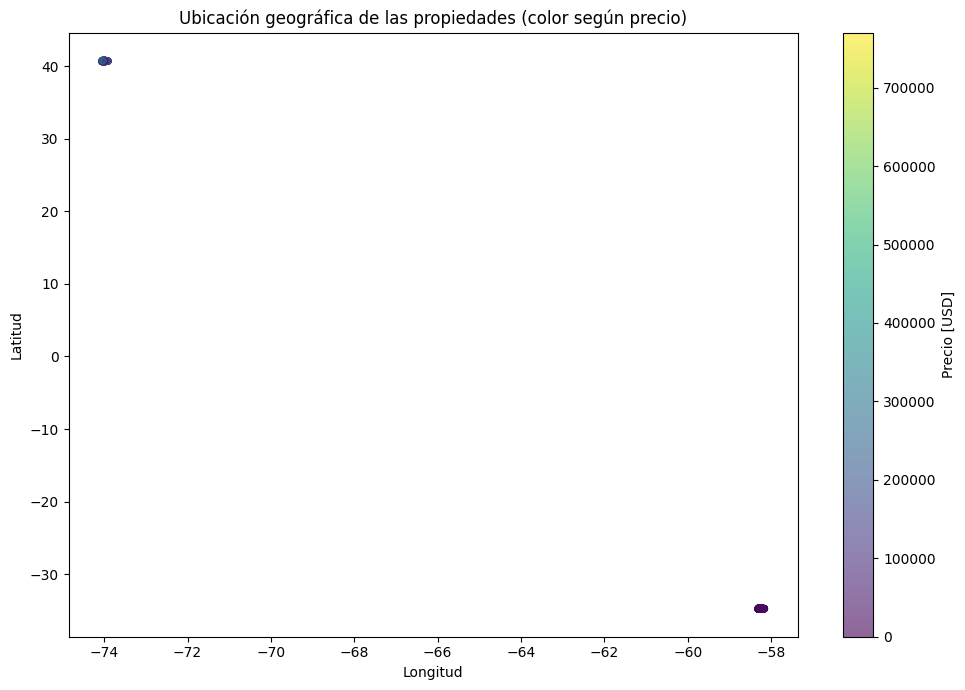

In [18]:
df_geo = df.dropna(subset=['precio'])

fig, ax = plt.subplots(figsize=(10, 7))
puntos = ax.scatter(df_geo['lon'], df_geo['lat'], c=df_geo['precio'],
                    cmap='viridis', alpha=0.6, s=18)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Ubicación geográfica de las propiedades (color según precio)')
fig.colorbar(puntos, ax=ax, label='Precio [USD]')
plt.tight_layout()
plt.show()

El análisis detallado de los histogramas y la dispersión geográfica permite ver lo siguiente:

Con respecto a la distribución de metros cuadrados vemos dos gaussianas separadas:
- La primera (entre 0 y 200) representa los metros cuadrados de las propiedades en Argentina.
- La segunda (centrada en 700-800) representa los pies cuadrados de las propiedades en USA.

Nuevamente refuerza lo que observamos en los scatterplots pero de una manera más clara. Luego, la distribución de edad muestra una concentración en propiedades jóvenes (0 a 20 años), con una caída más gradual hacia propiedades más antiguas. Esto indica un mercado con  una base de datos con sesgo hacia construcciones modernas.

Finalmente, con respecto a la ubicación, los histogramas de lat y lon muestran barras aisladas en los extremos del gráfico, y el scatter plot de longitud contra latitud permite ver la relación entre ambas variables de forma directa: los puntos forman dos clusters compactos y muy alejados entre sí (Argentina con latitud negativa y Estados Unidos con latitud positiva), sin observaciones intermedias. El color según el precio agrega una lectura adicional: el cluster de EE. UU. concentra los valores en dólares más altos del dataset. Esto anticipa que la información geográfica relevante para el modelo no es la coordenada exacta, sino la pertenencia a uno u otro mercado.


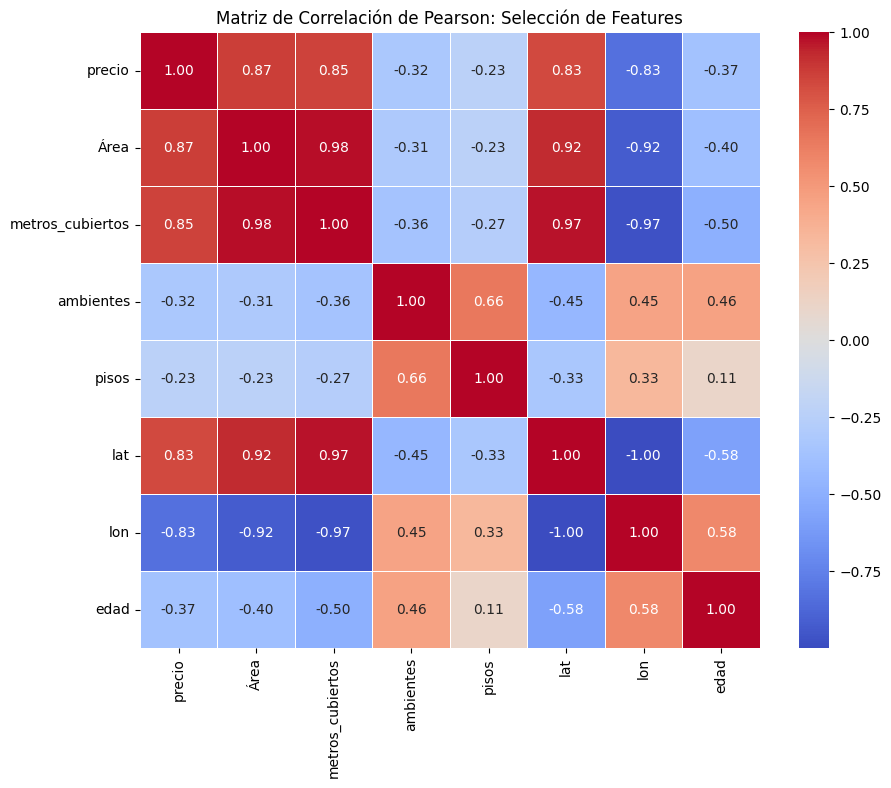

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f",
            linewidths=0.5)
plt.title("Matriz de Correlación de Pearson: Selección de Features")
plt.show()

La matriz de correlación nos permite identificar qué variables tienen mayor peso lineal sobre el precio y detectar posibles problemas de multicolinealidad:

Con respecto a área y metros_cubiertos vemos que ambas variables presentan la correlación más alta con el precio (0.87 y 0.85 respectivamente). Esto confirma que la superficie es un factor importante. También podemos observar que La correlación de 0.98 entre ellas indica que contienen prácticamente la misma información. 
Luego, podemos notar la correlación de 0.83 entre la latitud y el precio. En este dataset específico, los valores altos (USA) se asocian a precios más altos, mientras que valores bajos (Argentina) se asocian a la escala de precios local. Después, curiosamente, el número de ambientes y pisos muestra una correlación negativa o débil con el precio global (-0.32 y -0.23). Esto suele ocurrir porque el dataset mezcla tipos de propiedades muy distintos (como departamentos de lujo pequeños vs. casas grandes pero baratas), o debido a la gran cantidad de datos faltantes en estas columnas que no permite ver la relación lineal.
Finalmente, la correlación negativa de -0.37 entre edad y precio indica que, en general, las propiedades más antiguas tienden a tener un menor valor de mercado. Si bien este efecto no es tan fuerte como el de la superficie, sigue siendo un factor relevante que el modelo debe considerar.

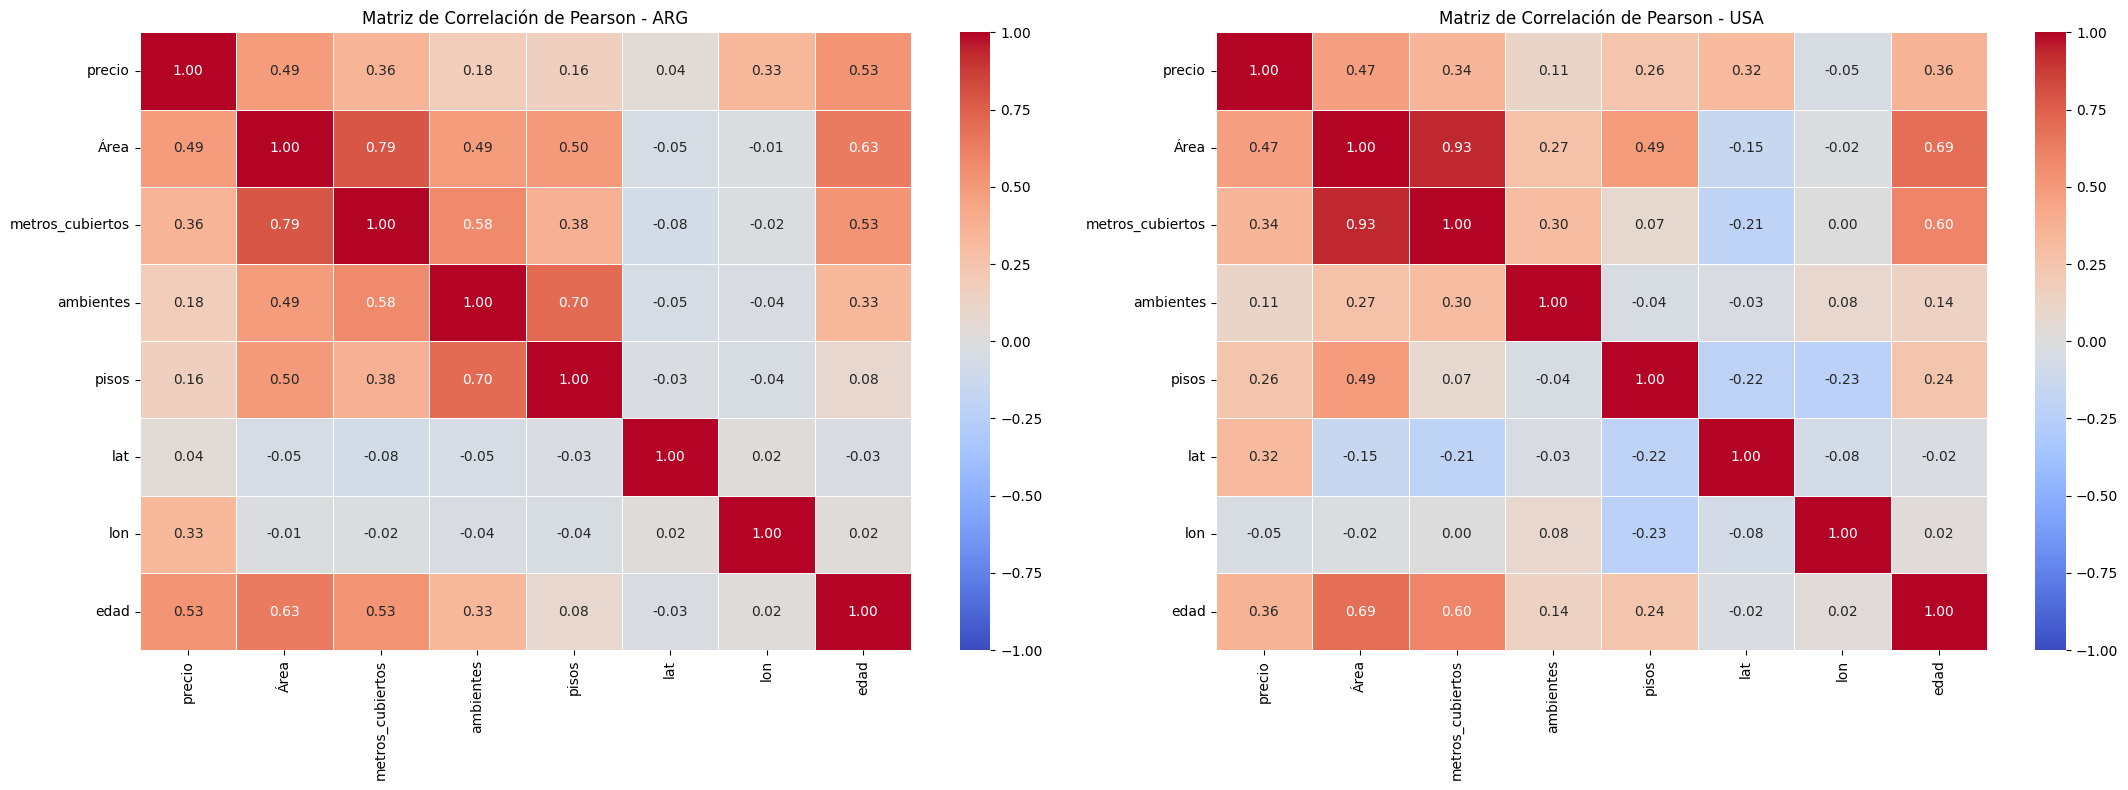

In [20]:
df_corr = df.copy()
df_corr['pais'] = np.where(df_corr['lat'] > 0, 'USA', 'ARG')

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
for ax, pais in zip(axes, ['ARG', 'USA']):
    corr = df_corr[df_corr['pais'] == pais].select_dtypes(include=[np.number]).corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,
                vmin=-1, vmax=1, ax=ax)
    ax.set_title(f"Matriz de Correlación de Pearson - {pais}")
plt.tight_layout()
plt.show()

Dado que el target mostró una estructura bimodal asociada a la coexistencia de dos mercados (Buenos Aires y Estados Unidos), la matriz de correlación global puede resultar engañosa: buena parte de las correlaciones que muestra no reflejan relaciones dentro de un mercado, sino la diferencia entre mercados. Por eso repetimos el análisis estratificando por país, y los resultados cambian de manera notable.

El caso más llamativo es el de edad: globalmente correlacionaba negativo con el precio (-0.37), pero dentro de cada país la correlación es positiva (0.53 en Argentina y 0.36 en EE. UU.). Es un ejemplo clásico de la paradoja de Simpson: el mercado estadounidense combina precios en dólares más altos con propiedades en promedio más nuevas, de modo que al mezclar ambos países la relación aparente se invierte. Algo similar ocurre con ambientes y pisos, cuyas correlaciones globales eran negativas (-0.32 y -0.23) y dentro de cada mercado pasan a ser positivas, que es el signo que la intuición inmobiliaria esperaría.

En la dirección opuesta, la correlación de la superficie con el precio, que globalmente parecía altísima (0.87 para Área), baja a valores mucho más moderados dentro de cada país (0.49 en Argentina y 0.47 en EE. UU.). La cifra global estaba inflada por un efecto de composición: las propiedades de EE. UU. tienen a la vez números de superficie más grandes (por estar expresados en sqft) y precios más altos, lo que estira artificialmente la relación lineal. Por último, las coordenadas pierden casi todo su poder explicativo dentro de cada país (lat pasa de 0.83 global a 0.04 dentro de Argentina), confirmando que su valor predictivo provenía de separar los dos mercados y no de un gradiente geográfico fino.

Este análisis estratificado refuerza dos decisiones que atraviesan el resto del trabajo: unificar las unidades de superficie y tratar la pertenencia al mercado (país) como una variable de primer orden en el modelado.

### 1.3) División del conjunto de datos

Antes de dividir, conviene detenerse en un riesgo de la división puramente aleatoria: nada garantiza que los dos subconjuntos resulten representativos. Con mala suerte, validación podría quedar poblada mayormente por propiedades muy caras (o muy baratas), y las métricas medidas allí no reflejarían el desempeño real del modelo. En este dataset el riesgo es doble: no solo importa cubrir todo el rango de precios, sino también respetar la proporción de propiedades de cada país, ya que conviven dos mercados con escalas muy distintas.

Para no depender de la suerte —ni de tener que verificar a posteriori que la división salió bien y repetirla si no—, realizamos una división estratificada: definimos estratos combinando el país con el cuartil de precio dentro de cada país, y muestreamos el 80/20 por separado dentro de cada estrato. De este modo, ambos conjuntos preservan por construcción la proporción de cada mercado y de cada rango de precios.

In [21]:
import pandas as pd
import numpy as np
from src.data_splitting import stratified_train_val_split

df_dev = pd.read_csv('../data/raw/casas_dev.csv')
X_raw = df_dev.drop(columns=['precio']).values
y_raw = df_dev['precio'].values.reshape(-1, 1)

# Estratos: país (según latitud) x cuartil de precio dentro de cada país.
# Los registros sin precio forman su propio estrato (_q-1) para repartirse de forma pareja.
pais = np.where(df_dev['lat'] > 0, 'USA', 'ARG')
cuartil = df_dev.groupby(pais)['precio'].transform(lambda s: pd.qcut(s, q=4, labels=False))
estratos = pd.Series(pais, index=df_dev.index) + "_q" + cuartil.fillna(-1).astype(int).astype(str)

X_train_raw, X_val_raw, y_train_raw, y_val_raw = stratified_train_val_split(
    X_raw,
    y_raw,
    estratos.values,
    train_size=0.8,
    seed=42
)

print(f"Muestras para entrenamiento: {X_train_raw.shape[0]}")
print(f"Muestras para validación: {X_val_raw.shape[0]}")

Muestras para entrenamiento: 1280
Muestras para validación: 320


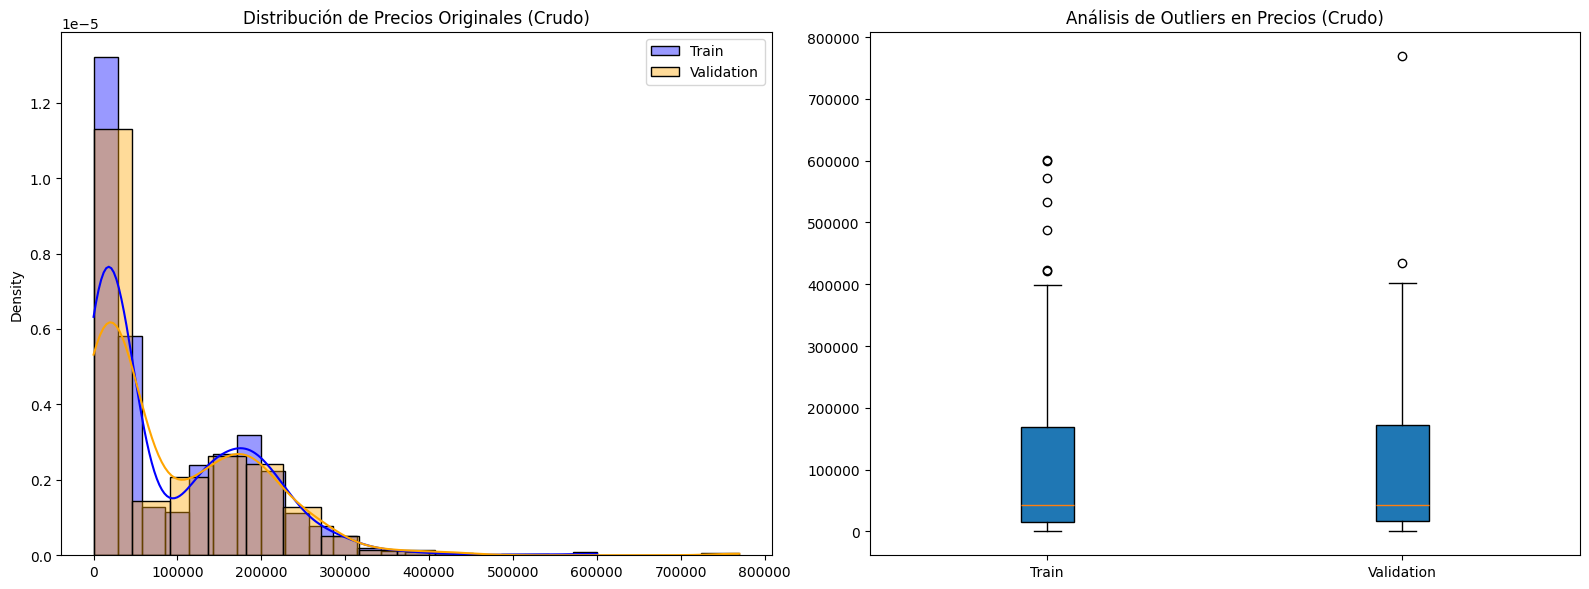

Muestras para entrenamiento: 1280
Muestras para validación: 320
Media Precio Train: 93031.39
Media Precio Val:   94592.92


In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

y_train_plot = y_train_raw[~np.isnan(y_train_raw)]
y_val_plot = y_val_raw[~np.isnan(y_val_raw)]

sns.histplot(y_train_plot, kde=True, color="blue", label="Train", stat="density", ax=ax1, alpha=0.4)
sns.histplot(y_val_plot, kde=True, color="orange", label="Validation", stat="density", ax=ax1, alpha=0.4)
ax1.set_title("Distribución de Precios Originales (Crudo)")
ax1.legend()

ax2.boxplot([y_train_plot, y_val_plot], 
            tick_labels=['Train', 'Validation'],
            patch_artist=True)
ax2.set_title("Análisis de Outliers en Precios (Crudo)")

plt.tight_layout()
plt.show()

print(f"Muestras para entrenamiento: {X_train_raw.shape[0]}")
print(f"Muestras para validación: {X_val_raw.shape[0]}")
print(f"Media Precio Train: {np.nanmean(y_train_raw):.2f}")
print(f"Media Precio Val:   {np.nanmean(y_val_raw):.2f}")

Como era de esperar por construcción, la distribución de precios en validación replica fielmente la de entrenamiento: las medias son muy cercanas y los histogramas prácticamente se superponen. A diferencia de una división aleatoria simple —donde este chequeo podría fallar por mala suerte y obligaría a repetir la división—, con la división estratificada esta verificación deja de ser una condición a comprobar y pasa a ser una simple confirmación de que el procedimiento se aplicó correctamente.

## 2.  Implementación Inicial

In [23]:
from src.preprocessing import preprocess_data, refine_features
from src.preprocessing import normalize

output_dir = "../data/processed/"
os.makedirs(output_dir, exist_ok=True)

nombres_columnas = df_dev.drop(columns=['precio']).columns
df_train = pd.DataFrame(X_train_raw, columns=nombres_columnas)
df_train['precio'] = y_train_raw

df_train_clean, imput_stats = preprocess_data(df_train)
df_train_processed, cats_tipo = refine_features(df_train_clean)
print(f"Estadísticos de imputación calculados sobre train: {imput_stats}")

df_train_processed.to_csv(f"{output_dir}/df_train_processed.csv", index=False)
print(f"Guardado df_train_processed.csv en {output_dir}")

# Selección manual de features, asegurando que metros_cubiertos quede incluida
# Agregamos las columnas del One-Hot dinámicamente
cols_ohe = [f"tipo_{cat}" for cat in cats_tipo[1:]] 
cols_base = ['Área','metros_cubiertos', 'ambientes', 'pisos', 'pileta', 'lat', 'lon', 'edad']
cols_finales = [c for c in cols_base + cols_ohe if c in df_train_processed.columns]

df_train_numeric = df_train_processed[cols_finales + ['precio']]

X_train_final = df_train_numeric.drop(columns=['precio']).values
y_train_final = df_train_numeric['precio'].values.reshape(-1, 1)

X_train_norm, mu_X, sigma_X = normalize(X_train_final)
y_train_norm, mu_y, sigma_y = normalize(y_train_final)


Estadísticos de imputación calculados sobre train: {'edad_mediana': np.float64(13.187594483482314), 'pisos_moda': np.float64(3.0)}
Guardado df_train_processed.csv en ../data/processed/


#### Justificación tratamiento de valores faltantes

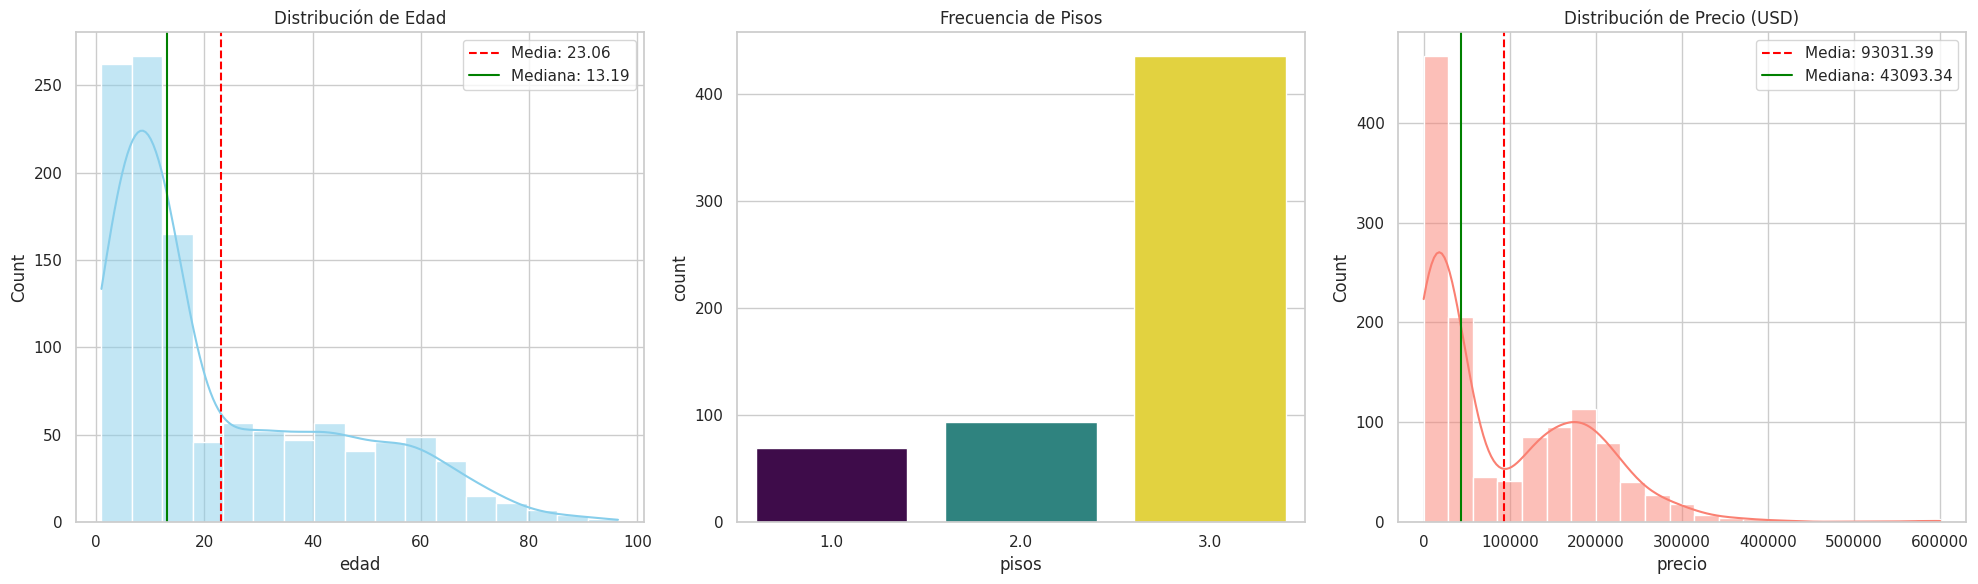

In [24]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(df_train['edad'], kde=True, color="skyblue", ax=axes[0])
axes[0].axvline(df_train['edad'].mean(), color='red', linestyle='--', label=f"Media: {df_train['edad'].mean():.2f}")
axes[0].axvline(df_train['edad'].median(), color='green', linestyle='-', label=f"Mediana: {df_train['edad'].median():.2f}")
axes[0].set_title("Distribución de Edad")
axes[0].legend()

sns.countplot(data=df_train, x='pisos', hue='pisos', palette="viridis", ax=axes[1], legend=False)
axes[1].set_title("Frecuencia de Pisos")

sns.histplot(df_train['precio'], kde=True, color="salmon", ax=axes[2])
axes[2].axvline(df_train['precio'].mean(), color='red', linestyle='--', label=f"Media: {df_train['precio'].mean():.2f}")
axes[2].axvline(df_train['precio'].median(), color='green', linestyle='-', label=f"Mediana: {df_train['precio'].median():.2f}")
axes[2].set_title("Distribución de Precio (USD)")
axes[2].legend()

plt.tight_layout()
plt.show()

En primer lugar, para la variable objetivo precio, se decidió eliminar los registros con valores nulos. Esta decisión se debe a que el precio es la variable que el modelo intenta predecir, por lo que imputar valores faltantes podría distorsionar la relación real entre las variables explicativas y el valor económico. Al eliminar estos casos, se asegura que el modelo aprenda únicamente a partir de datos reales.

En cuanto a la variable edad de la propiedad, se optó por imputar los valores faltantes utilizando la mediana. Esto se debe a que la antigüedad suele tener una relación inversa con el precio (propiedades más antiguas tienden a valer menos) y, dado que la distribución puede estar sesgada o contener valores extremos, la mediana resulta una medida más robusta que el promedio para representar una propiedad típica.

Por último, para la variable pisos, se decidió imputar utilizando la moda calculada sobre el conjunto de entrenamiento (3 pisos). Al tratarse de una variable discreta vinculada a la estructura del inmueble, el uso de la media podría generar valores no realistas (como decimales). En cambio, la moda permite mantener la coherencia con los tipos de propiedades presentes en el dataset.

Por último, un detalle metodológico importante: los estadísticos utilizados para imputar (la mediana de edad y la moda de pisos) se calculan exclusivamente sobre el conjunto de entrenamiento y se reutilizan, como parámetros fijos, para imputar los conjuntos de validación y test. Si cada conjunto se imputara con sus propios estadísticos, información de validación/test se filtraría al pipeline (data leakage) y la evaluación dejaría de simular el escenario real, en el que los datos nuevos llegan de a uno y solo se dispone de lo aprendido durante el entrenamiento.

### 2.1) Implementación de la clase de Regresión Lineal: realizado en models.py

### 2.2) Implementación del MSE: realizado en metrics.py

### 2.3) Verificación de implementación

In [25]:
df_val = pd.DataFrame(X_val_raw, columns=nombres_columnas)
df_val['precio'] = y_val_raw

print(cats_tipo)
df_val_clean, _ = preprocess_data(df_val, stats=imput_stats)
df_val_processed, _ = refine_features(df_val_clean, cats_tipo=cats_tipo)

df_val_processed.to_csv(f"{output_dir}/df_val_processed.csv", index=False)
print(f"Guardado df_val_processed.csv en {output_dir}")

df_val_numeric = df_val_processed[cols_finales + ['precio']]
print(df_val_numeric.columns)


X_val_final = df_val_numeric.drop(columns=['precio']).values
y_val_final = df_val_numeric['precio'].values.reshape(-1, 1)

X_val_norm, _, _ = normalize(X_val_final, mu=mu_X, sigma=sigma_X)
y_val_norm, _, _ = normalize(y_val_final, mu=mu_y, sigma=sigma_y)


['casa', 'depto', 'ph']
Guardado df_val_processed.csv en ../data/processed/
Index(['Área', 'metros_cubiertos', 'ambientes', 'pisos', 'pileta', 'lat',
       'lon', 'edad', 'tipo_depto', 'tipo_ph', 'precio'],
      dtype='object')


#### Modelo univariado

In [26]:
from src.models import LinearRegression
from src.metrics import rmse
from src.preprocessing import denormalize

y_train_usd = denormalize(y_train_norm, mu_y, sigma_y)
y_val_usd = denormalize(y_val_norm, mu_y, sigma_y)

idx_m2 = cols_finales.index('metros_cubiertos')
X_train_uni = X_train_norm[:, [idx_m2]]
X_val_uni = X_val_norm[:, [idx_m2]]

model_uni = LinearRegression(X_train_uni, y_train_norm)
model_uni.fit_pseudo_inverse()

y_train_pred_uni = denormalize(model_uni.predict(X_train_uni), mu_y, sigma_y)
y_val_pred_uni = denormalize(model_uni.predict(X_val_uni), mu_y, sigma_y)

#### Modelo multivariado

In [27]:
model_multi = LinearRegression(X_train_norm, y_train_norm)
model_multi.fit_pseudo_inverse()

y_train_pred_multi = denormalize(model_multi.predict(X_train_norm), mu_y, sigma_y)
y_val_pred_multi = denormalize(model_multi.predict(X_val_norm), mu_y, sigma_y)


In [28]:
# Verificación adicional: los mismos dos modelos, ahora ajustados por descenso de gradiente
model_uni_gd = LinearRegression(X_train_uni, y_train_norm)
model_uni_gd.fit_gradient_descent(lr=0.01, epochs=5000)

model_multi_gd = LinearRegression(X_train_norm, y_train_norm)
model_multi_gd.fit_gradient_descent(lr=0.01, epochs=5000)

y_train_pred_uni_gd = denormalize(model_uni_gd.predict(X_train_uni), mu_y, sigma_y)
y_val_pred_uni_gd = denormalize(model_uni_gd.predict(X_val_uni), mu_y, sigma_y)
y_train_pred_multi_gd = denormalize(model_multi_gd.predict(X_train_norm), mu_y, sigma_y)
y_val_pred_multi_gd = denormalize(model_multi_gd.predict(X_val_norm), mu_y, sigma_y)

diff_uni = np.max(np.abs(model_uni.coef - model_uni_gd.coef))
diff_multi = np.max(np.abs(model_multi.coef - model_multi_gd.coef))
print(f"Máxima diferencia absoluta entre coeficientes (univariado): {diff_uni:.2e}")
print(f"Máxima diferencia absoluta entre coeficientes (multivariado): {diff_multi:.2e}")

Máxima diferencia absoluta entre coeficientes (univariado): 1.28e-15
Máxima diferencia absoluta entre coeficientes (multivariado): 1.16e+01


In [29]:
print("Verificación: pseudo-inversa vs. descenso de gradiente")
print()
print("Modelo univariado (metros_cubiertos)")
print(f"  Pseudo-inversa        -> RMSE Train: {rmse(y_train_usd, y_train_pred_uni):.2f} USD | RMSE Val: {rmse(y_val_usd, y_val_pred_uni):.2f} USD")
print(f"  Descenso de gradiente -> RMSE Train: {rmse(y_train_usd, y_train_pred_uni_gd):.2f} USD | RMSE Val: {rmse(y_val_usd, y_val_pred_uni_gd):.2f} USD")
print()
print("Modelo multivariado (todas las variables)")
print(f"  Pseudo-inversa        -> RMSE Train: {rmse(y_train_usd, y_train_pred_multi):.2f} USD | RMSE Val: {rmse(y_val_usd, y_val_pred_multi):.2f} USD")
print(f"  Descenso de gradiente -> RMSE Train: {rmse(y_train_usd, y_train_pred_multi_gd):.2f} USD | RMSE Val: {rmse(y_val_usd, y_val_pred_multi_gd):.2f} USD")

Verificación: pseudo-inversa vs. descenso de gradiente

Modelo univariado (metros_cubiertos)
  Pseudo-inversa        -> RMSE Train: 83029.68 USD | RMSE Val: 87998.78 USD
  Descenso de gradiente -> RMSE Train: 83029.68 USD | RMSE Val: 87998.78 USD

Modelo multivariado (todas las variables)
  Pseudo-inversa        -> RMSE Train: 44404.12 USD | RMSE Val: 51236.69 USD
  Descenso de gradiente -> RMSE Train: 44704.31 USD | RMSE Val: 51450.30 USD


La verificación se apoya en una propiedad teórica de la regresión lineal: el MSE es una función convexa de los pesos, cuyo mínimo global viene dado por la solución de cuadrados mínimos $w^* = (X^T X)^{-1} X^T y$ (calculada aquí mediante la pseudo-inversa). Por lo tanto, si ambas implementaciones son correctas, el descenso por gradiente —que aproxima el mínimo de forma iterativa— debe alcanzar la misma solución o, al menos, el mismo valor de la función de costo.

En el modelo univariado ocurre exactamente eso: la diferencia máxima entre los coeficientes de ambos métodos es del orden de $10^{-15}$ (precisión de máquina) y los RMSE coinciden hasta el centavo. En el multivariado, en cambio, los coeficientes difieren de forma apreciable mientras que los RMSE resultan prácticamente iguales (44,404 vs 44,704 USD en train). Esta aparente contradicción tiene una explicación interesante: el dataset contiene features casi colineales (por ejemplo, Área y metros_cubiertos, con correlación 0.98), lo que genera "valles" casi planos en la superficie de costo, es decir, muchas combinaciones de pesos con un error casi idéntico. La pseudo-inversa selecciona una de esas soluciones, y el descenso por gradiente, que avanza muy lentamente a lo largo de las direcciones de poca curvatura, se detiene en otra solución cercana en costo aunque distinta en coeficientes. La coincidencia del error —que es lo que la convexidad garantiza— confirma que ambas implementaciones optimizan correctamente la misma función.

## 3. Aplicación de Modelos de Regresión

### 3.1) Implementación de modelos M1 y M2

#### Modelo M1

In [30]:
idx_area = cols_finales.index('Área')

X_train_m1 = X_train_norm[:, [idx_area]]
X_val_m1 = X_val_norm[:, [idx_area]]

model_m1 = LinearRegression(X_train_m1, y_train_norm)
model_m1.fit_pseudo_inverse()

y_train_pred_m1_norm = model_m1.predict(X_train_m1)
y_val_pred_m1_norm = model_m1.predict(X_val_m1)

y_train_pred_m1_usd = denormalize(y_train_pred_m1_norm, mu_y, sigma_y)
y_val_pred_m1_usd = denormalize(y_val_pred_m1_norm, mu_y, sigma_y)
y_train_usd = denormalize(y_train_norm, mu_y, sigma_y)
y_val_usd = denormalize(y_val_norm, mu_y, sigma_y)

print("Modelo M1: usando Área")
print(f"RMSE Train: {rmse(y_train_usd, y_train_pred_m1_usd):.2f} USD")
print(f"RMSE Val: {rmse(y_val_usd, y_val_pred_m1_usd):.2f} USD")
print(f"Pendiente: {model_m1.coef[1][0]}")
print(f"Bias: {model_m1.coef[0][0]}")

Modelo M1: usando Área
RMSE Train: 79605.65 USD
RMSE Val: 85164.94 USD
Pendiente: -0.5544105133280197
Bias: 6.982261990806649e-17


#### Modelo M2

In [31]:
from src.models import LinearRegression
from src.metrics import rmse
from src.preprocessing import denormalize

idx_area = cols_finales.index('metros_cubiertos')
idx_pileta = cols_finales.index('pileta')

indices_m2 = [idx_area, idx_pileta]

X_train_m2 = X_train_norm[:, indices_m2]
X_val_m2 = X_val_norm[:, indices_m2]

model_m2 = LinearRegression(X_train_m2, y_train_norm)
model_m2.fit_gradient_descent()

y_train_pred_m2 = denormalize(model_m2.predict(X_train_m2), mu_y, sigma_y)
y_val_pred_m2 = denormalize(model_m2.predict(X_val_m2), mu_y, sigma_y)

print("Modelo M2: área y pileta")
print(f"RMSE Train: {rmse(y_train_usd, y_train_pred_m2):.2f} USD")
print(f"RMSE Val: {rmse(y_val_usd, y_val_pred_m2):.2f} USD")
print(f"Coeficiente Área: {model_m2.coef[1][0]}")
print(f"Coeficiente Pileta: {model_m2.coef[2][0]}")
print(f"Intercepto: {model_m2.coef[0][0]}")

Modelo M2: área y pileta
RMSE Train: 82374.79 USD
RMSE Val: 87349.71 USD
Coeficiente Área: -0.4447045755754668
Coeficiente Pileta: -0.12050525018893272
Intercepto: -2.7287229432130532e-17


### 3.2) Construcción de una pileta

In [32]:
impacto_pileta_usd = model_m2.coef[2][0] * sigma_y[0]

print(f"Análisis de impacto:")
if impacto_pileta_usd > 0:
    print(f"Construir una pileta incrementa el valor en: {impacto_pileta_usd:.2f} USD")
else:
    print(f"El impacto calculado es {impacto_pileta_usd:.2f} USD.")

Análisis de impacto:
El impacto calculado es -11526.56 USD.


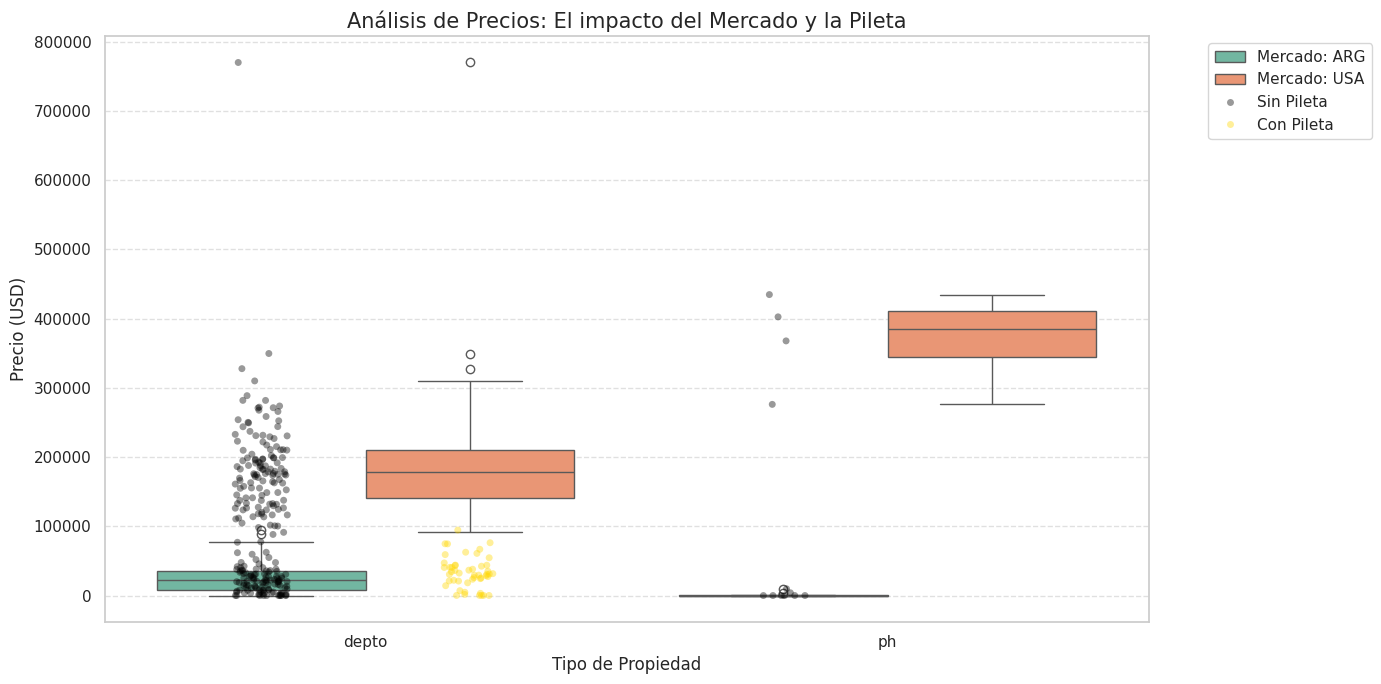

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cols_tipo = [c for c in df_val_processed.columns if c.startswith('tipo_')]

# Creamos una serie temporal que"deshace el One-Hot solo para el eje X
# idxmax busca cuál de las columnas tipo_ tiene el '1' y nos da el nombre
tipo_recuperado = df_val_processed[cols_tipo].idxmax(axis=1).str.replace('tipo_', '')

plt.figure(figsize=(14, 7))

sns.boxplot(
    x=tipo_recuperado, 
    y=df_val_processed['precio'], 
    hue=df_val_processed['lat'] > 0, 
    palette='Set2'
)

sns.stripplot(
    x=tipo_recuperado, 
    y=df_val_processed['precio'], 
    hue=df_val_processed['pileta'], 
    dodge=True, 
    palette={1.0: 'gold', 0.0: 'black'},
    alpha=0.4,
    jitter=True
)

plt.title('Análisis de Precios: El impacto del Mercado y la Pileta', fontsize=15)
plt.ylabel('Precio (USD)')
plt.xlabel('Tipo de Propiedad')

handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ['Mercado: ARG', 'Mercado: USA', 'Sin Pileta', 'Con Pileta']
plt.legend(handles[0:4], new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Al analizar el Modelo M2 (Área + Pileta), se observa un coeficiente negativo de -$11,526.56 USD, lo que a priori sugeriría que la construcción de una pileta resta valor a la propiedad. Sin embargo, este resultado es un hallazgo importante que nos habla de la naturaleza del dataset y no una pérdida de valor real.

Como en el grafico, el modelo está procesando dos mercados inmobiliarios con escalas de precios en dólares totalmente disitintos. En el segmento de EE. UU., existe una alta concentración de departamentos de lujo que, por su tipología, carecen de pileta pero poseen los precios más elevados del dataset (puntos negros en la zona superior). En contraste, en el mercado de Argentina, se encuentran casas con pileta (puntos amarillos) cuyos precios en dólares son significativamente menores debido al contexto económico local.

Al intentar ajustar una única regresión global, el algoritmo interpreta la presencia de la pileta como una variable indicadora de pertenencia al mercado argentino. Por lo tanto, el signo negativo es un artefacto estadístico que captura la brecha de precios entre países y no el valor intrínseco de la pileta.

### 3.3) Implementación de modelo M3


In [34]:

features_m3 = ['metros_cubiertos', 'ambientes', 'pisos', 'pileta', 'edad', 'tipo_depto']
indices_m3 = [cols_finales.index(f) for f in features_m3]

X_train_m3 = X_train_norm[:, indices_m3]
X_val_m3 = X_val_norm[:, indices_m3]

model_m3 = LinearRegression(X_train_m3, y_train_norm)
model_m3.fit_gradient_descent()

y_train_pred_m3_norm = model_m3.predict(X_train_m3)
y_val_pred_m3_norm = model_m3.predict(X_val_m3)

y_train_pred_m3_usd = denormalize(y_train_pred_m3_norm, mu_y, sigma_y)
y_val_pred_m3_usd = denormalize(y_val_pred_m3_norm, mu_y, sigma_y)


print("Modelo M3: Regresión usando 6 características")
print(f"RMSE Train: {rmse(y_train_usd, y_train_pred_m3_usd):.2f} USD")
print(f"RMSE Val: {rmse(y_val_usd, y_val_pred_m3_usd):.2f} USD")
print("Coeficientes:")
model_m3.print_coefficients(features_m3)

Modelo M3: Regresión usando 6 características
RMSE Train: 80456.89 USD
RMSE Val: 86793.49 USD
Coeficientes:
Variable | Weight
Intercepto: 0.000000
metros_cubiertos: -0.167629
ambientes: 0.041218
pisos: -0.128286
pileta: -0.058311
edad: 0.050328
tipo_depto: 0.451154


## 4. Feature Engineering

### 4.1 Construcción de características derivadas a partir de las originales

In [35]:
from src.feature_engineering import apply_feature_engineering

La etapa de Feature Engineering se diseñó con el objetivo de darle al modelo de una mejor idea sobre el contexto geográfico y la naturaleza no lineal de ciertos aspectos del dataset.
Primeramente, se incorporaron las variables metros_cubiertos_2 (término cuadrático) y log_m2 (transformación logarítmica) para modelar mejor la relación entre la superficie y el precio. Esto permite que el modelo entienda que el valor de una propiedad no aumenta siempre al mismo ritmo por cada metro adicional, sino que ese crecimiento tiende a desacelerarse en propiedades más grandes. Luego, debido a la bimodalidad detectada entre Argentina y EE. UU., se crearon variables de interacción como es_usa e interact_m2_usa. Estas permiten que el modelo ajuste una pendiente de precio distinta según la ubicación, intentando corregir el sesgo de intentar promediar dos economías con escalas de precios en dólares totalmente diferentes. Finalmente, se desarrollaron los atributos coef_zona y precio_estimado_cuadratico. Al calcular la relación mediana entre precio y superficie por país, estas variables intentan actuar como una referencia de mercado. Con esto se busca que el modelo tenga una cierta base comparativa, permitiéndole identificar si una propiedad está sobre o subvaluada respecto al comportamiento típico de su región geográfica. Es fundamental destacar que estas medianas fueron calculadas exclusivamente sobre el conjunto de entrenamiento y luego aplicadas como parámetros fijos a los conjuntos de validación y test.

### 4.2 Construcción de modelos M4 y M5

In [36]:
input_dir = "../data/processed"

df_train_processed = pd.read_csv(f"{input_dir}/df_train_processed.csv")
df_val_processed = pd.read_csv(f"{input_dir}/df_val_processed.csv")

print(f"Datasets cargados desde {input_dir}")
print(f"Tamaño Train: {df_train_processed.shape}")
print(f"Tamaño Val: {df_val_processed.shape}")
import os

df_train_m4, medians_train = apply_feature_engineering(df_train_processed)

print(f"Medianas calculadas en train: {medians_train}")

df_val_m4, _ = apply_feature_engineering(df_val_processed, medians_dict = medians_train)

output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

df_train_m4.to_csv(f"{output_dir}/train_m4_engineered.csv", index=False)
df_val_m4.to_csv(f"{output_dir}/val_m4_engineered.csv", index=False)


print("\nVista de df_train_m4")
print(df_train_m4.head())
print("\nColumnas nuevas creadas:", [c for c in df_train_m4.columns if c not in df_train_processed.columns])

Datasets cargados desde ../data/processed
Tamaño Train: (1190, 12)
Tamaño Val: (298, 12)
Medianas calculadas en train: {'prices': {'arg': 21640.799512782243, 'usa': 180854.265231726}, 'areas': {'arg': 119.09947756593468, 'usa': 67.48091021831871}}

Vista de df_train_m4
         Área  metros_cubiertos unidades  ambientes  pisos  pileta        lat  \
0   76.342648         73.861784       m2          4    3.0       0  40.824547   
1   67.852654         64.884402       m2          5    3.0       0  40.804939   
2  215.096074        144.471894       m2         10    3.0       0 -34.776746   
3   85.483453         83.647982       m2          4    3.0       0 -34.812448   
4  227.224178        107.557368       m2          7    3.0       0 -34.696205   

         lon       edad         precio  tipo_depto  tipo_ph  \
0 -74.048183  13.682270  189123.067134           1        0   
1 -74.008931   3.979901  303639.130208           1        0   
2 -58.219217  36.833608   69160.575079           0    

#### M4

In [37]:
features_m4 = [
    'metros_cubiertos','ambientes', 'pisos', 'pileta', 'edad', 'tipo_depto', 'tipo_ph',
    'metros_cubiertos_2', 'log_m2', 'interact_m2_usa', 'coef_zona', 'precio_estimado_cuadratico',
]

X_train_m4_raw = df_train_m4[features_m4].values.astype(np.float64)
X_val_m4_raw = df_val_m4[features_m4].values.astype(np.float64)

X_train_m4_norm, mu_X4, sigma_X4 = normalize(X_train_m4_raw)
X_val_m4_norm, _, _ = normalize(X_val_m4_raw, mu=mu_X4, sigma=sigma_X4)

# Se reutiliza y_train_norm (mismos mu_y y sigma_y de la sección 2): el target no cambió y
# mantener su escala hace que el RMSE sea directamente comparable entre M1, M2, M3 y M4.
model_m4 = LinearRegression(X_train_m4_norm, y_train_norm)
model_m4.fit_gradient_descent()

y_train_pred_m4 = denormalize(model_m4.predict(X_train_m4_norm), mu_y, sigma_y)
y_val_pred_m4 = denormalize(model_m4.predict(X_val_m4_norm), mu_y, sigma_y)

print("Modelo M4: M3 + Feature Engineering")
print(f"RMSE Train: {rmse(y_train_usd, y_train_pred_m4):.2f} USD")
print(f"RMSE Val: {rmse(y_val_usd, y_val_pred_m4):.2f} USD")
print("Coeficientes:")
model_m4.print_coefficients(features_m4)

Modelo M4: M3 + Feature Engineering
RMSE Train: 41306.24 USD
RMSE Val: 45392.10 USD
Coeficientes:
Variable | Weight
Intercepto: -0.000000
metros_cubiertos: -0.051484
ambientes: 0.003877
pisos: -0.000502
pileta: 0.008873
edad: 0.066622
tipo_depto: -0.371724
tipo_ph: -0.031994
metros_cubiertos_2: 0.310492
log_m2: -0.610419
interact_m2_usa: 0.169798
coef_zona: 0.464552
precio_estimado_cuadratico: 0.333459


#### M4 con el target transformado: log(precio)

En la sección 1.1 observamos que la distribución del precio es fuertemente asimétrica y dejamos planteado el experimento de transformar el target con un logaritmo. La intuición es que el logaritmo comprime la cola derecha de la distribución: los errores sobre las propiedades más caras dejan de dominar la función de costo, y el modelo pasa a ajustar errores relativos (porcentuales) en lugar de absolutos. Entrenamos entonces el mismo modelo M4, pero prediciendo log(precio); para poder comparar en igualdad de condiciones, invertimos la transformación con la exponencial y calculamos el RMSE en dólares.

In [38]:
y_train_log = np.log(df_train_m4['precio'].values.reshape(-1, 1))
y_train_log_norm, mu_ylog, sigma_ylog = normalize(y_train_log)

model_m4_log = LinearRegression(X_train_m4_norm, y_train_log_norm)
model_m4_log.fit_gradient_descent()

pred_train_log = denormalize(model_m4_log.predict(X_train_m4_norm), mu_ylog, sigma_ylog)
pred_val_log = denormalize(model_m4_log.predict(X_val_m4_norm), mu_ylog, sigma_ylog)

y_train_pred_m4_log = np.exp(pred_train_log)
y_val_pred_m4_log = np.exp(pred_val_log)

print("M4 con target log(precio) vs M4 original")
print(f"M4 log -> RMSE Train: {rmse(y_train_usd, y_train_pred_m4_log):.2f} USD | RMSE Val: {rmse(y_val_usd, y_val_pred_m4_log):.2f} USD")
print(f"M4     -> RMSE Train: {rmse(y_train_usd, y_train_pred_m4):.2f} USD | RMSE Val: {rmse(y_val_usd, y_val_pred_m4):.2f} USD")

M4 con target log(precio) vs M4 original
M4 log -> RMSE Train: 666746.17 USD | RMSE Val: 498255.62 USD
M4     -> RMSE Train: 41306.24 USD | RMSE Val: 45392.10 USD


El experimento confirma —de manera contundente— la decisión de mantener el target en su escala original: el RMSE en dólares del modelo entrenado sobre log(precio) empeora en un orden de magnitud (498,255 USD en validación contra 45,392 USD del M4 original). La causa está en la inversión de la transformación: al aplicar la exponencial, un error en la escala logarítmica se convierte en un error multiplicativo en dólares, de modo que una sobreestimación moderada del log-precio de una propiedad cara se transforma en una predicción desmesurada que domina por completo el promedio cuadrático. Dicho de otro modo, entrenar en escala logarítmica optimiza el error relativo, pero la métrica con la que evaluamos (RMSE en USD) castiga el error absoluto; ambos objetivos no coinciden en un dataset con una cola derecha tan larga. Por este motivo, el resto del trabajo mantiene el precio en su escala original.

#### M5

In [39]:
df_train_m5 = df_train_m4.copy() 
df_val_m5 = df_val_m4.copy()

para_expandir = ['metros_cubiertos', 'precio_estimado_cuadratico', 'coef_zona', 'interact_m2_usa', 'log_m2', 'lat']
features_m5 = list(features_m4) 

def expand_features(df, features_list):
    # Potencias (3, 4, 5)
    for p in [3, 4, 5]:
        for col in para_expandir:
            new_col = f"{col}_{p}"
            df[new_col] = df[col] ** p
            if new_col not in features_list:
                features_list.append(new_col)
    
    # Interacciones entre variables
    for i, col1 in enumerate(para_expandir):
        for col2 in para_expandir[i+1:]:
            new_col = f"inter_{col1}_{col2}"
            df[new_col] = df[col1] * df[col2]
            if new_col not in features_list:
                features_list.append(new_col)
    
    # Interacciones con zona de usa
    for col in para_expandir:
        new_col = f"{col}_x_usa"
        df[new_col] = df[col] * df['is_usa']
        if new_col not in features_list:
            features_list.append(new_col)
            
    return df, features_list

df_train_m5, full_features = expand_features(df_train_m5, features_m5)
df_val_m5, _ = expand_features(df_val_m5, list(features_m4))

# Limitamos a las primeras 50 como pide consigna
features_m5_final = full_features[:50]
print(f"Listas las {len(features_m5_final)} features para el M5.")
print(features_m5_final)

Listas las 50 features para el M5.
['metros_cubiertos', 'ambientes', 'pisos', 'pileta', 'edad', 'tipo_depto', 'tipo_ph', 'metros_cubiertos_2', 'log_m2', 'interact_m2_usa', 'coef_zona', 'precio_estimado_cuadratico', 'metros_cubiertos_3', 'precio_estimado_cuadratico_3', 'coef_zona_3', 'interact_m2_usa_3', 'log_m2_3', 'lat_3', 'metros_cubiertos_4', 'precio_estimado_cuadratico_4', 'coef_zona_4', 'interact_m2_usa_4', 'log_m2_4', 'lat_4', 'metros_cubiertos_5', 'precio_estimado_cuadratico_5', 'coef_zona_5', 'interact_m2_usa_5', 'log_m2_5', 'lat_5', 'inter_metros_cubiertos_precio_estimado_cuadratico', 'inter_metros_cubiertos_coef_zona', 'inter_metros_cubiertos_interact_m2_usa', 'inter_metros_cubiertos_log_m2', 'inter_metros_cubiertos_lat', 'inter_precio_estimado_cuadratico_coef_zona', 'inter_precio_estimado_cuadratico_interact_m2_usa', 'inter_precio_estimado_cuadratico_log_m2', 'inter_precio_estimado_cuadratico_lat', 'inter_coef_zona_interact_m2_usa', 'inter_coef_zona_log_m2', 'inter_coef_zona

Justificación de la Selección de Variables para Expansión (M5)

Para cumplir con el requisito de construir un modelo de 50 features, se decidió aplicar técnicas de expansión polinómica e interacciones sobre un subconjunto específico de variables: metros_cubiertos, precio_estimado_cuadratico, coef_zona, interact_m2_usa, log_m2, lat.

La elección de estas variables no fue arbitraria, sino que responde a su relevancia demostrada en etapas previas del modelado. En particular, se priorizaron aquellas variables generadas durante el feature engineering como coef_zona y log_m2 debido a que ya habían mostrado un fuerte impacto en la reducción del error en el modelo M4. Al expandir estas variables a potencias superiores ($x^3, x^4, x^5$), se busca capturar relaciones más complejas y curvaturas más sutiles en la relación entre superficie y precio, que no pueden ser modeladas únicamente con términos lineales o cuadráticos.

Además, se incorporaron interacciones entre estas variables y la variable indicadora de región (is_usa) con el objetivo de modelar diferencias más específicas entre mercados. De esta manera, el modelo no solo distingue entre países, sino que también puede capturar variaciones en cómo cambian los precios dentro de cada región, por ejemplo, en la forma en que el precio responde a incrementos en la superficie.

Por otro lado, se incluyeron interacciones entre variables (productos cruzados) porque el valor de una propiedad no depende solo de cada característica por separado, sino también de cómo se combinan entre sí. 

In [40]:
X_train_m5_raw = df_train_m5[features_m5_final].values.astype(np.float64)
X_val_m5_raw = df_val_m5[features_m5_final].values.astype(np.float64)
y_train_m5_raw = df_train_m5['precio'].values.reshape(-1, 1)

X_train_m5_norm, mu_X5, sigma_X5 = normalize(X_train_m5_raw)
X_val_m5_norm, _, _ = normalize(X_val_m5_raw, mu=mu_X5, sigma=sigma_X5)

# Con potencias de grado 5 los valores crecen enormemente (por ejemplo, 200^5 = 3.2e11), por lo
# que se renormalizan X e y localmente para estabilizar el descenso por gradiente. La
# desnormalización final devuelve las predicciones a USD y mantiene el RMSE comparable.
y_train_m5_norm, mu_y_m5, sigma_y_m5 = normalize(y_train_m5_raw)

model_m5 = LinearRegression(X_train_m5_norm, y_train_m5_norm)
model_m5.fit_gradient_descent()

y_train_pred_m5 = denormalize(model_m5.predict(X_train_m5_norm), mu_y_m5, sigma_y_m5)
y_val_pred_m5 = denormalize(model_m5.predict(X_val_m5_norm), mu_y_m5, sigma_y_m5)

print("Modelo M5: 50 features")
print(f"RMSE Train: {rmse(y_train_m5_raw, y_train_pred_m5):.2f} USD")
print(f"RMSE Val: {rmse(y_val_usd, y_val_pred_m5):.2f} USD")

Modelo M5: 50 features
RMSE Train: 40384.85 USD
RMSE Val: 44102.92 USD


### 4.3 Resultados de experimentos

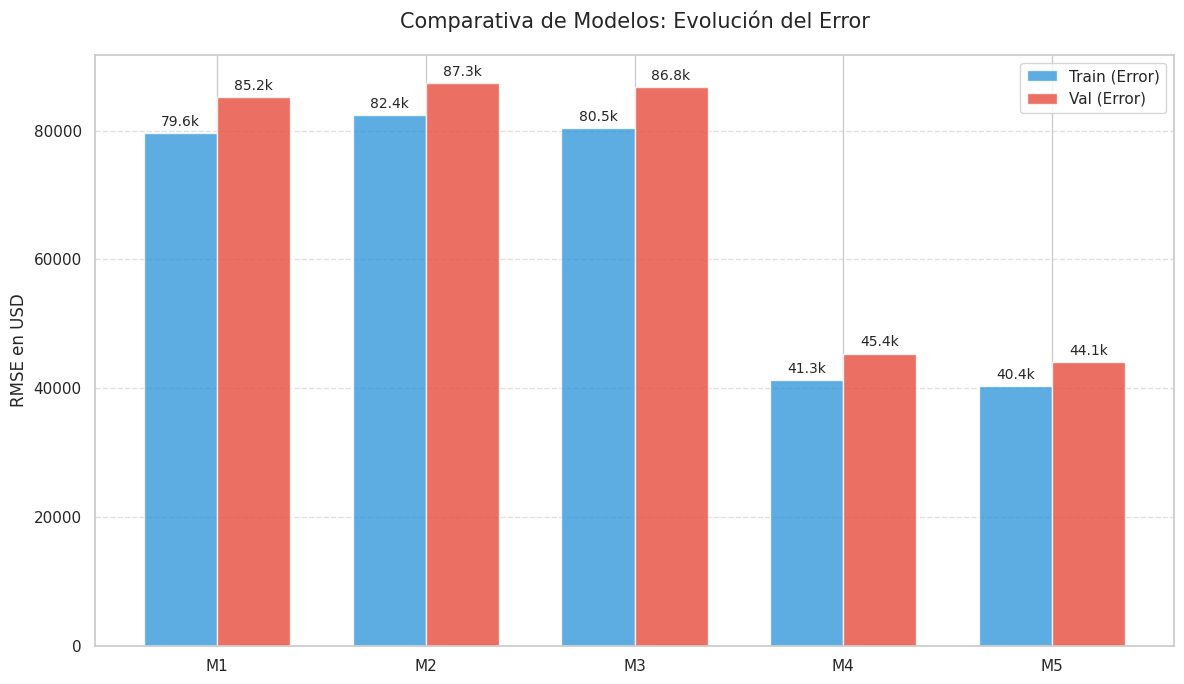

In [41]:
import matplotlib.pyplot as plt
import numpy as np

resultados = {
    'M1': {
        'train': rmse(y_train_usd, y_train_pred_m1_usd), 
        'val': rmse(y_val_usd, y_val_pred_m1_usd)
    },
    'M2': {
        'train': rmse(y_train_usd, y_train_pred_m2), 
        'val': rmse(y_val_usd, y_val_pred_m2)
    },
    'M3': {
        'train': rmse(y_train_usd, y_train_pred_m3_usd), 
        'val': rmse(y_val_usd, y_val_pred_m3_usd)
    },
    'M4': {
        'train': rmse(y_train_usd, y_train_pred_m4), 
        'val': rmse(y_val_usd, y_val_pred_m4)
    },
    'M5': {
        'train': rmse(y_train_usd, y_train_pred_m5), 
        'val': rmse(y_val_usd, y_val_pred_m5)
    }
}

labels = list(resultados.keys())
train_vals = [v['train'] for v in resultados.values()]
val_vals = [v['val'] for v in resultados.values()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, train_vals, width, label='Train (Error)', color='#3498db', alpha=0.8)
rects2 = ax.bar(x + width/2, val_vals, width, label='Val (Error)', color='#e74c3c', alpha=0.8)

ax.set_ylabel('RMSE en USD')
ax.set_title('Comparativa de Modelos: Evolución del Error', fontsize=15, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height/1000:.1f}k',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Al diseñar los experimentos M4 y M5, el objetivo principal fue incrementar la capacidad del modelo para capturar relaciones no lineales y dependencias entre variables, las cuales no pueden ser correctamente modeladas mediante una regresión lineal simple.

En primer lugar, el salto de M3 a M4 resulta especialmente significativo. Si bien se esperaba que la incorporación de técnicas de feature engineering produjera una mejora en el desempeño, la magnitud de la reducción del error fue notable: el RMSE en validación descendió de aproximadamente 86.8k USD (M3) a 45.4k USD (M4). Esta mejora puede explicarse, en parte, porque en el modelo M3 no se utilizaron variables geográficas como lat o lon, lo que limitaba la capacidad del modelo para capturar diferencias estructurales entre regiones. En M4, en cambio, se decidió incorporar lat a la hora de trabajar en el feature engineering (evitando incluir ambas coordenadas para reducir problemas de multicolinealidad), lo que permitió introducir información geográfica relevante.

Además, se agregaron variables derivadas como interact_m2_usa y log_m2 y otras previamente justificadas, que permitieron al modelo capturar relaciones más complejas. En particular, estas transformaciones ayudan a modelar el hecho de que el valor de un metro cuadrado no es homogéneo entre países, sino que depende del contexto geográfico y del mercado correspondiente.

Al pasar de M4 a M5, donde se incorporan 50 características, se esperaba una mejora adicional, aunque más moderada. Efectivamente, el RMSE de validación disminuyó de 45.4k USD a 44.1k USD. Este resultado sugiere que el aumento en la complejidad del modelo aporta información adicional, aunque con rendimientos decrecientes.

Por otro lado, se anticipaba el riesgo de overfitting, es decir, una posible ampliación de la brecha entre el error de entrenamiento y el de validación. Sin embargo, los resultados muestran que el RMSE de entrenamiento (~40.4k USD) y el de validación (~44.1k USD) se mantienen cercanos. Esta brecha moderada y estable indica que, a pesar de la alta cantidad de variables utilizadas, el modelo no ha caído en un overfitting fuerte.

#### Distribución de residuos y análisis

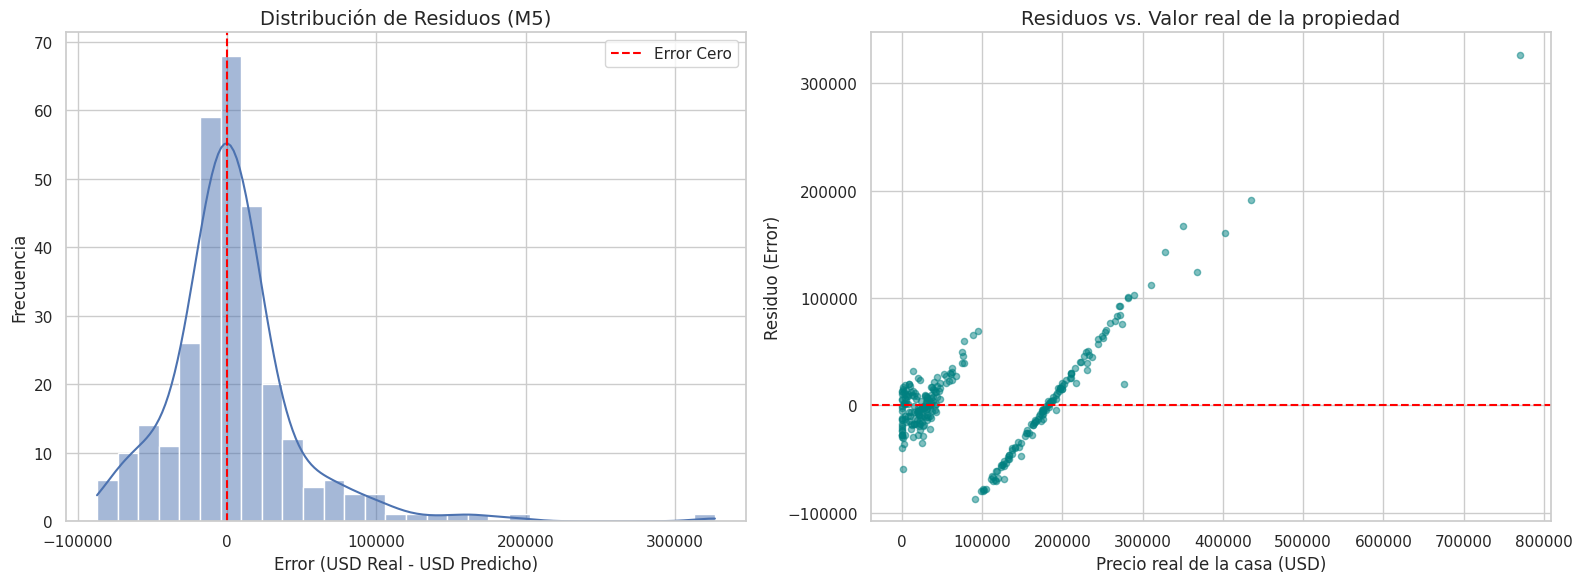

In [42]:
residuos_m5 = y_val_usd - y_val_pred_m5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(residuos_m5, kde=True, ax=ax1, color='purple', bins=30)
ax1.axvline(0, color='red', linestyle='--', label='Error Cero')
ax1.set_title('Distribución de Residuos (M5)', fontsize=14)
ax1.set_xlabel('Error (USD Real - USD Predicho)')
ax1.set_ylabel('Frecuencia')
ax1.legend()

ax2.scatter(y_val_usd, residuos_m5, alpha=0.5, color='teal', s=20)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_title('Residuos vs. Valor real de la propiedad', fontsize=14)
ax2.set_xlabel('Precio real de la casa (USD)')
ax2.set_ylabel('Residuo (Error)')

plt.tight_layout()
plt.show()

Para evaluar la fiabilidad del modelo de mayor complejidad (M5), se realizó un análisis detallado de los residuos, es decir, de los errores de predicción. Esto nos permite ver el nivel de error y entender en qué regiones del espacio de datos el modelo presenta mayores dificultades.

En primer lugar, al observar la distribución de los residuos, se aprecia que estos se distribuyen de manera aproximadamente simétrica alrededor del valor cero. Esta característica es relevante, ya que indica que el modelo no presenta un sesgo sistemático, o sea, en promedio, no tiende ni a sobreestimar ni a subestimar los precios. Además, la forma gaussiana de la distribución sugiere que la mayoría de los errores son relativamente pequeños y se concentran cerca del centro.

Sin embargo, al analizar los residuos en función del valor real de la variable objetivo, surge un patrón. En lugar de observar una dispersión aleatoria, los puntos tienden a organizarse en dos trayectorias diagonales bien diferenciadas. Este comportamiento refleja la estructura del dataset: la existencia de dos mercados distintos, correspondientes a Argentina y Estados Unidos.

Este patrón evidencia que el modelo está intentando ajustar una única relación lineal para describir dos realidades económicas diferentes. Como consecuencia, se generan errores sistemáticos en distintos rangos de precios: el modelo tiende a sobreestimar en algunos segmentos y a subestimar en otros. De este modo, podemos pensar que la varianza del error no se mantiene constante a lo largo de los valores de la variable objetivo.

Ante esta evidencia, nos podemos cuestionar que tan eficaz es una única regresión lineal. La presencia de estas "dos trayectorias" sugiere que los coeficientes óptimos para el mercado argentino difieren significativamente de los estadounidenses. Por lo tanto, surge naturalmente la idea de una estrategia de segmentación geográfica: entrenar modelos independientes para cada país permitiría capturar las dinámicas locales con mayor precisión. Por eso, a continuación se entrena un modelo con las 50 features de M5 pero segmentado por país.

#### M5 pero segmentado por país

In [43]:
import numpy as np
from src.utils import train_segmented_model

df_train_usa = df_train_m5[df_train_m5['is_usa'] == 1].copy()
df_train_arg = df_train_m5[df_train_m5['is_usa'] == 0].copy()

df_val_usa = df_val_m5[df_val_m5['is_usa'] == 1].copy()
df_val_arg = df_val_m5[df_val_m5['is_usa'] == 0].copy()

res_usa = train_segmented_model(df_train_usa, df_val_usa, features_m5_final)
res_arg = train_segmented_model(df_train_arg, df_val_arg, features_m5_final)

# Concatenamos los vectores de predicciones y valores reales de cada región
# para calcular una métrica global. No promediamos los resultados de cada 
# región individualmente, ya que si las regiones tienen distinto número 
# de muestras, el promedio simple no sería representativo del error real.
y_train_total_raw = np.vstack((res_usa[5], res_arg[5]))
y_train_total_pred = np.vstack((res_usa[6], res_arg[6]))

y_val_total_raw = np.vstack((res_usa[7], res_arg[7]))
y_val_total_pred = np.vstack((res_usa[8], res_arg[8]))

print("Resultados modelo m5 segmentado")
print(f"RMSE Train USA: {rmse(res_usa[5], res_usa[6]):.2f} USD")
print(f"RMSE Val USA: {rmse(res_usa[7], res_usa[8]):.2f} USD")
print(f"RMSE Train ARG: {rmse(res_arg[5], res_arg[6]):.2f} USD")
print(f"RMSE Val ARG: {rmse(res_arg[7], res_arg[8]):.2f} USD")
print(f"RMSE global train: {rmse(y_train_total_raw, y_train_total_pred):.2f} USD")
# El RMSE global refleja el error esperado sobre el dataset de validación completo
print(f"RMSE global val: {rmse(y_val_total_raw, y_val_total_pred):.2f} USD")

Resultados modelo m5 segmentado
RMSE Train USA: 48267.30 USD
RMSE Val USA: 46825.87 USD
RMSE Train ARG: 15563.26 USD
RMSE Val ARG: 16524.03 USD
RMSE global train: 33950.75 USD
RMSE global val: 33323.58 USD


Para calcular la métrica global (RMSE global), no se promediaron los errores de cada segmento por separado, sino que primero se unieron todas las predicciones en un único conjunto y luego se calculó el error total.

Se procedió de esta forma para que cada observación tenga el mismo peso en el resultado final. Si simplemente se promediaran los errores de cada región, se podría distorsionar la métrica, especialmente si una región tiene muchas más observaciones que otra. En cambio, al trabajar con todos los datos juntos, se obtiene una medida más representativa y general del modelo.

## 5. Regularización


### 5.1 Modificación de la clase LinearRegression (realizado en modelo.py)

### 5.2 M4 con Ridge Regression

Lambda | RMSE Val (USD)
0.000001 | 44134.29
0.000100 | 44134.17
0.010000 | 44125.10
0.100000 | 44155.54
1.000000 | 44669.23
10.000000 | 45674.26
100.000000 | 47646.56
1000.000000 | 54693.29
10000.000000 | 78943.88


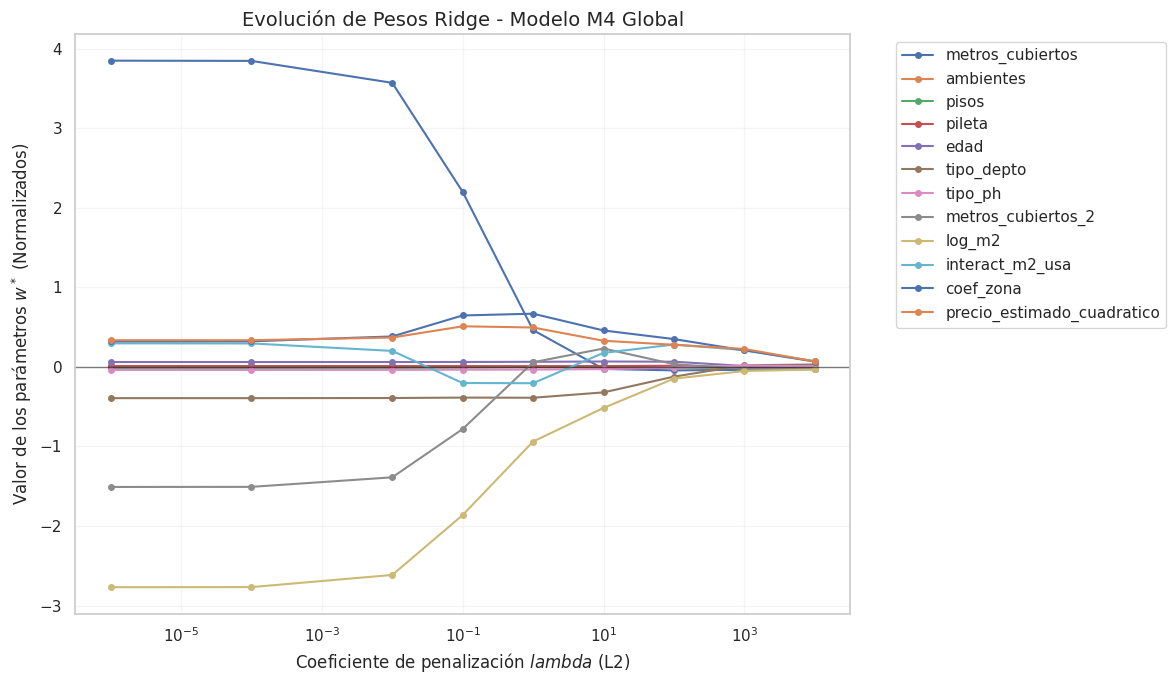

In [44]:
import matplotlib.pyplot as plt
import numpy as np

df_train_m4 = pd.read_csv("../data/processed/train_m4_engineered.csv")
df_val_m4 = pd.read_csv("../data/processed/val_m4_engineered.csv")

features_m4 = [
    'metros_cubiertos','ambientes', 'pisos', 'pileta', 'edad', 'tipo_depto', 'tipo_ph',
    'metros_cubiertos_2', 'log_m2', 'interact_m2_usa', 'coef_zona', 'precio_estimado_cuadratico',
]

X_train_raw = df_train_m4[features_m4].values
y_train_raw = df_train_m4['precio'].values.reshape(-1, 1)

X_val_raw = df_val_m4[features_m4].values
y_val_raw = df_val_m4['precio'].values.reshape(-1, 1)

# La regularización depende de la escala de los coeficientes: trabajar con X e y
# estandarizados permite usar un rango de lambda estándar y ver el shrinkage con claridad.
X_train_norm, mu_X, sigma_X = normalize(X_train_raw)
y_train_norm, mu_y, sigma_y = normalize(y_train_raw)
X_val_norm, _, _ = normalize(X_val_raw, mu=mu_X, sigma=sigma_X)

l2_range = [1e-6, 1e-4, 1e-2, 0.1, 1, 10, 100, 1000, 10000]
coefs_path = []

print(f"Lambda | RMSE Val (USD)")

for lam in l2_range:
    model_ridge = LinearRegression(X_train_norm, y_train_norm, l2=lam)
    model_ridge.fit_pseudo_inverse()
    
    # Guardamos los coeficientes (sin el bias del índice 0)
    coefs_path.append(model_ridge.coef.flatten()[1:])
    
    pred_norm = model_ridge.predict(X_val_norm)
    pred_usd = denormalize(pred_norm, mu_y, sigma_y)
    error = rmse(y_val_raw, pred_usd)
    
    print(f"{lam:.6f} | {error:.2f}")

coefs_path = np.array(coefs_path)

plt.figure(figsize=(12, 7))
for i in range(len(features_m4)):
    plt.plot(l2_range, coefs_path[:, i], label=features_m4[i], marker='o', markersize=4)

plt.xscale('log')
plt.xlabel('Coeficiente de penalización $lambda$ (L2)', fontsize=12)
plt.ylabel('Valor de los parámetros $w^*$ (Normalizados)', fontsize=12)
plt.title('Evolución de Pesos Ridge - Modelo M4 Global', fontsize=14)
plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 5.3 M4 con Lasso Regression

Lambda L1 | RMSE Val (USD)
0.00000 | 45100.91
0.00010 | 45107.40


0.00050 | 45135.18
0.00100 | 45168.78


0.00500 | 45530.13
0.01000 | 46099.25


0.05000 | 49203.69
0.10000 | 49924.98


0.50000 | 57395.31


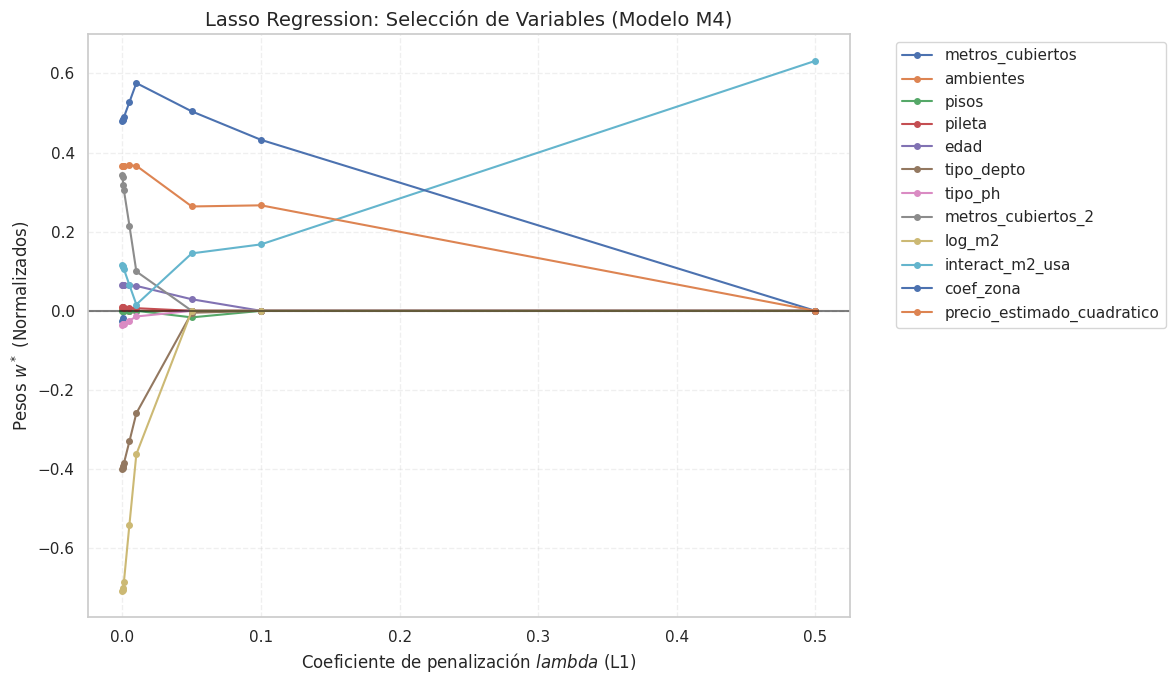

In [45]:
l1_range = [0, 1e-4, 5e-4, 1e-3, 5e-3, 0.01, 0.05, 0.1, 0.5]
coefs_path_l1 = []
rmses_val_l1 = []

print(f"Lambda L1 | RMSE Val (USD)")

for lam in l1_range:
    model_lasso = LinearRegression(X_train_norm, y_train_norm, l1=lam, l2=0)
    
    model_lasso.fit_gradient_descent(lr=0.01, epochs=8000)
    
    # Guardamos pesos (sin el bias)
    coefs_path_l1.append(model_lasso.coef.flatten()[1:])
    
    y_p_norm = model_lasso.predict(X_val_norm)
    y_p_usd = denormalize(y_p_norm, mu_y, sigma_y)
    curr_rmse = rmse(y_val_raw, y_p_usd)
    rmses_val_l1.append(curr_rmse)
    
    print(f"{lam:.5f} | {curr_rmse:.2f}")

coefs_path_l1 = np.array(coefs_path_l1)

plt.figure(figsize=(12, 7))
for i, feat in enumerate(features_m4):
    plt.plot(l1_range, coefs_path_l1[:, i], label=feat, marker='o', markersize=4)

plt.xlabel('Coeficiente de penalización $lambda$ (L1)', fontsize=12)
plt.ylabel('Pesos $w^*$ (Normalizados)', fontsize=12)
plt.title('Lasso Regression: Selección de Variables (Modelo M4)', fontsize=14)
plt.axhline(0, color='black', lw=1.5, alpha=0.5) # Línea base en cero
plt.grid(True, ls="--", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Análisis del gráfico obtenido y comparación con Ridge Regression

##### ¿Qué conclusiones se pueden extraer en cuanto al efecto de utilizar regularización L1 vs. L2?

La principal diferencia que observamos en los gráficos es cómo los modelos manejan la importancia de las variables a medida que aumenta la penalización ($\lambda$):
En cuanto a Ridge (L2), vemos que se reducen los pesos de todas las variables de forma gradual. Ninguna llega exactamente a cero de forma abrupta. En cambio, el modelo intenta que todos los coeficientes sean pequeños para evitar que una sola variable domine, pero mantiene la información de todas ellas. 
En cuanto a Lasso (L1), se observa que muchos coeficientes (como tipo_ph, pisos o pileta) se reducen a cero muy rápidamente. Esto ocurre porque Lasso actúa como un mecanismo de selección de variables, eliminando aquellas que considera redundantes o poco informativas. Esta es la diferencia fundamental entre ambos enfoques: mientras Lasso produce un modelo más simple, conservando solo las variables más relevantes, Ridge, en cambio, mantiene todas las variables en el modelo, aunque reduciendo su influencia.

##### ¿Cuáles son las features más importantes?

Para identificar las variables más importantes, es útil observar cuáles son las que más tardan en desaparecer en el caso de Lasso, o aquellas que mantienen los valores absolutos más altos bajo penalización en Ridge.

En este sentido, coef_zona se destaca claramente en ambos modelos, ya que presenta un peso positivo elevado y una gran persistencia. Esto valida el proceso feature engineering, confirmando que la relación entre precio y metro cuadrado según la zona es un predictor clave. Además, se observa que en el gráfico de lasso precio_estimado_cuadrático también tiene un gran relevancia.

Por otro lado, la variable interact_m2_usa muestra un comportamiento extraño en el gráfico de Lasso. A diferencia de los demás coeficientes, esta variable no solo persiste ante la penalización, sino que su magnitud tiende a aumentar y finalmente diverge. Técnicamente, podemos pensar que es una inestabilidad numérica del gradiente descendente (gd). Al ser Lasso un método que apaga variables correlacionadas (como metros_cubiertos o log_m2), la variable de interacción queda como el único sustento para explicar la varianza del mercado estadounidense. Ante la falta de una solución analítica y la no-diferenciabilidad de la norma L1 en cero, el gd pierde estabilidad y dispara el peso de esta variable en un intento de compensar el error residual. 

Finalmente, las variables metros_cubiertos y log_m2 funcionan como la base del modelo en términos de tamaño de la propiedad. Estas variables sostienen la capacidad predictiva inicial y permanecen relevantes hasta que la penalización se vuelve suficientemente fuerte como para reducir su influencia.

##### ¿Cuáles son las features menos importantes?

Las variables menos importantes pueden identificarse como aquellas que desaparecen rápidamente en Lasso o que presentan coeficientes cercanos a cero desde el inicio en Ridge.

En este grupo se encuentran pileta, pisos y tipo_ph. En el caso de Lasso, estas variables son las primeras en reducirse a cero incluso ante aumentos mínimos de lambda, lo que sugiere que, en presencia de variables más informativas como la zona o las interacciones geográficas, su aporte adicional es muy limitado.

Por su parte, tipo_depto, aunque comienza con un coeficiente negativo relativamente significativo, pierde relevancia rápidamente a medida que aumenta la penalización, especialmente en comparación con variables estructurales como coef_zona.

Finalmente, la variable edad presenta un comportamiento prácticamente nulo a lo largo de todo el recorrido en ambos modelos. Esto indica que, para este dataset en particular, la antigüedad de la propiedad no resulta un factor determinante del precio cuando se consideran variables más influyentes como la superficie y la ubicación.

### 5.4 Cross validation para lambda y creación de M6

In [46]:
from src.data_splitting import cross_val

In [47]:
df_train_m4 = pd.read_csv("../data/processed/train_m4_engineered.csv")

features_m4 = [
    'metros_cubiertos','ambientes', 'pisos', 'pileta', 'edad', 'tipo_depto', 'tipo_ph',
    'metros_cubiertos_2', 'log_m2', 'interact_m2_usa', 'coef_zona', 'precio_estimado_cuadratico',
]


X_m6_raw = df_train_m4[features_m4].values
y_m6_raw = df_train_m4['precio'].values.reshape(-1, 1)

X_m6_norm, mu_X, sigma_X = normalize(X_m6_raw)
y_m6_norm, mu_y, sigma_y = normalize(y_m6_raw)

In [48]:
lambdas = np.logspace(-5, 3, 25) 
ridge_cv_errors = []
lasso_cv_errors = []

print(f"Lambda | RMSE Ridge (USD) | RMSE Lasso (USD)")

for l in lambdas:
    err_r = cross_val(X_m6_norm, y_m6_norm, mu_y, sigma_y, k=5, l2=l, method='pinv')
    ridge_cv_errors.append(err_r)
    
    err_l = cross_val(X_m6_norm, y_m6_norm, mu_y, sigma_y, k=5, l1=l, method='gd', lr=0.01, epochs=3000)
    lasso_cv_errors.append(err_l)
    
    print(f"{l:5f} | {err_r:.2f} | {err_l:.2f}")

best_lambda_ridge = lambdas[np.argmin(ridge_cv_errors)]
best_lambda_lasso = lambdas[np.argmin(lasso_cv_errors)]

print(f"Mejor Lambda Ridge: {best_lambda_ridge:.6f} (RMSE: {min(ridge_cv_errors):.2f} USD)")
print(f"Mejor Lambda Lasso: {best_lambda_lasso:.6f} (RMSE: {min(lasso_cv_errors):.2f} USD)")

Lambda | RMSE Ridge (USD) | RMSE Lasso (USD)


0.000010 | 41860.27 | 42620.86


0.000022 | 41484.28 | 42164.30


0.000046 | 41926.04 | 41769.03


0.000100 | 41580.61 | 41909.11


...

46.415888 | 42604.74 | 95578.47


100.000000 | 43161.86 | 95543.45


215.443469 | 44530.41 | 95606.84


464.158883 | 46045.10 | 95538.12


1000.000000 | 50452.25 | 95472.56
Mejor Lambda Ridge: 0.000464 (RMSE: 41202.13 USD)
Mejor Lambda Lasso: 0.001000 (RMSE: 41690.58 USD)


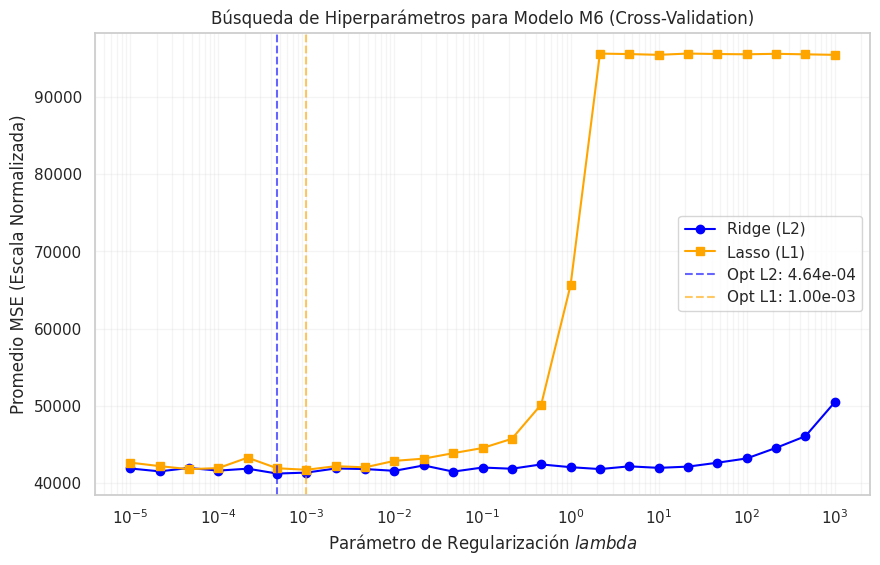


El mejor modelo Ridge usa lambda = 0.00046415888336127773
El mejor modelo Lasso usa lambda = 0.001


In [49]:
plt.figure(figsize=(10, 6))
plt.plot(lambdas, ridge_cv_errors, label='Ridge (L2)', marker='o', color='blue')
plt.plot(lambdas, lasso_cv_errors, label='Lasso (L1)', marker='s', color='orange')

plt.axvline(best_lambda_ridge, color='blue', linestyle='--', alpha=0.6, label=f'Opt L2: {best_lambda_ridge:.2e}')
plt.axvline(best_lambda_lasso, color='orange', linestyle='--', alpha=0.6, label=f'Opt L1: {best_lambda_lasso:.2e}')

plt.xscale('log')
plt.xlabel('Parámetro de Regularización $lambda$')
plt.ylabel('Promedio MSE (Escala Normalizada)')
plt.title('Búsqueda de Hiperparámetros para Modelo M6 (Cross-Validation)')
plt.legend()
plt.grid(True, which="both", alpha=0.2)
plt.show()

print(f"\nEl mejor modelo Ridge usa lambda = {best_lambda_ridge}")
print(f"El mejor modelo Lasso usa lambda = {best_lambda_lasso}")

In [50]:
m_ridge_m6 = LinearRegression(X_m6_norm, y_m6_norm, l2=best_lambda_ridge)
m_ridge_m6.fit_gradient_descent()

m_lasso_m6 = LinearRegression(X_m6_norm, y_m6_norm, l1=best_lambda_lasso)
m_lasso_m6.fit_gradient_descent(lr=0.01, epochs=5000)

In [51]:
X_train_raw = df_train_m4[features_m4].values
y_train_raw = df_train_m4['precio'].values.reshape(-1, 1)
X_train_norm, _, _ = normalize(X_train_raw, mu=mu_X, sigma=sigma_X)

X_val_raw = df_val_m4[features_m4].values
y_val_raw = df_val_m4['precio'].values.reshape(-1, 1)
X_val_norm, _, _ = normalize(X_val_raw, mu=mu_X, sigma=sigma_X)

pred_r_norm_train = m_ridge_m6.predict(X_train_norm)
res_ridge_train = denormalize(pred_r_norm_train, mu_y, sigma_y)
rmse_r_train = rmse(y_train_raw, res_ridge_train)

pred_r_norm_val = m_ridge_m6.predict(X_val_norm)
res_ridge_val = denormalize(pred_r_norm_val, mu_y, sigma_y)
rmse_r_val = rmse(y_val_raw, res_ridge_val)

pred_l_norm_train = m_lasso_m6.predict(X_train_norm)
res_lasso_train = denormalize(pred_l_norm_train, mu_y, sigma_y)
rmse_l_train = rmse(y_train_raw, res_lasso_train)

pred_l_norm_val = m_lasso_m6.predict(X_val_norm)
res_lasso_val = denormalize(pred_l_norm_val, mu_y, sigma_y)
rmse_l_val = rmse(y_val_raw, res_lasso_val)

print("Resumen de modelo M6 (Basado en M4)")
print(f"RIDGE-RMSE Train: {rmse_r_train:.2f} USD")
print(f"RIDGE-RMSE Val: {rmse_r_val:.2f} USD")
print(f"LASSO-RMSE Train: {rmse_l_train:.2f} USD")
print(f"LASSO-RMSE Val: {rmse_l_val:.2f} USD")

Resumen de modelo M6 (Basado en M4)
RIDGE-RMSE Train: 41315.12 USD
RIDGE-RMSE Val: 45419.85 USD
LASSO-RMSE Train: 41325.86 USD
LASSO-RMSE Val: 45470.22 USD


A partir de los resultados en validación, ambas variantes quedan prácticamente empatadas: Ridge alcanza 45,419.85 USD y Lasso 45,470.22 USD, una diferencia de ~50 USD que es despreciable frente a la escala del error. Ninguna de las dos mejora al M4 sin regularizar (45,392.10 USD). Para la comparación final de la parte 6 conservamos la variante Lasso que, ante la igualdad de desempeño, ofrece una ventaja adicional: produce un modelo más simple al llevar a cero los coeficientes menos informativos.

#### Prueba de regularización para el m5
Resulta interesante aplicar también regularización al modelo M5, con el objetivo de mitigar el riesgo de overfitting en el modelo de 50 características. Al introducir una penalización sobre la magnitud de los coeficientes, buscamos reducir la varianza del estimador y garantizar que el modelo no memorice el ruido de los datos de entrenamiento.

In [52]:
X_m6_high_raw = df_train_m5[features_m5_final].values.astype(np.float64)
y_m6_high_raw = df_train_m5['precio'].values.reshape(-1, 1)

X_m6_high_norm, mu_X6, sigma_X6 = normalize(X_m6_high_raw)
y_m6_high_norm, mu_y6, sigma_y6 = normalize(y_m6_high_raw)

In [53]:
lambdas = np.logspace(-5, 3, 25) 
ridge_cv_errors = []

print(f"Lambda | RMSE Ridge (USD)")

for l in lambdas:
    err_r = cross_val(X_m6_high_norm, y_m6_high_norm, mu_y6, sigma_y6, k=5, l2=l, method='pinv')
    ridge_cv_errors.append(err_r)
    print(f"{l:5f}|{err_r:.2f}")

best_lambda_m6_ridge = lambdas[np.argmin(ridge_cv_errors)]
print(f"\n Mejor lambda para M6 (basado en M5): {best_lambda_m6_ridge}")

Lambda | RMSE Ridge (USD)
0.000010|37389.70
0.000022|36229.19
0.000046|36073.86
0.000100|36017.78
0.000215|36436.74
0.000464|35834.20
0.001000|35641.65
0.002154|35845.67


0.004642|37315.94
0.010000|39343.67
0.021544|37022.81
0.046416|38406.77
0.100000|38601.39
0.215443|43022.45
0.464159|41361.65
1.000000|41428.34
2.154435|41573.44
4.641589|45558.01
10.000000|41835.09
21.544347|43161.99
46.415888|42891.07
100.000000|43491.46
215.443469|43031.47
464.158883|43589.79
1000.000000|44036.72

 Mejor lambda para M6 (basado en M5): 0.001


In [54]:
model_m6_final = LinearRegression(X_m6_high_norm, y_m6_high_norm, l2=best_lambda_m6_ridge)
model_m6_final.fit_gradient_descent() 

y_train_pred_m6_norm = model_m6_final.predict(X_m6_high_norm)
y_train_pred_m6 = denormalize(y_train_pred_m6_norm, mu_y6, sigma_y6)

X_val_m6_raw = df_val_m5[features_m5_final].values.astype(np.float64)
X_val_m6_norm, _, _ = normalize(X_val_m6_raw, mu=mu_X6, sigma=sigma_X6)
y_val_pred_m6_norm = model_m6_final.predict(X_val_m6_norm)
y_val_pred_m6 = denormalize(y_val_pred_m6_norm, mu_y6, sigma_y6)

rmse_train_m6 = rmse(y_train_usd, y_train_pred_m6)
rmse_val_m6 = rmse(y_val_usd, y_val_pred_m6)

print("M5 (sin regularizar) VS M6 (regularizado con ridge)")
print(f"M5-RMSE Train: {rmse(y_train_usd, y_train_pred_m5):.2f} USD")
print(f"M5-RMSE Val: {rmse(y_val_usd, y_val_pred_m5):.2f} USD")
print(f"M6-RMSE Train: {rmse_train_m6:.2f} USD")
print(f"M6-RMSE Val: {rmse_val_m6:.2f} USD")

M5 (sin regularizar) VS M6 (regularizado con ridge)
M5-RMSE Train: 40384.85 USD
M5-RMSE Val: 44102.92 USD
M6-RMSE Train: 40412.54 USD
M6-RMSE Val: 44166.97 USD


In [55]:
lambdas_lasso = np.logspace(-5, 1, 25) 
lasso_cv_errors = []

print("Lambda | RMSE Lasso (USD)")

for l in lambdas_lasso:
    err_l = cross_val(X_m6_high_norm, y_m6_high_norm, mu_y6, sigma_y6, k=5, l1=l, method='gd', lr=0.01, epochs=3000)
    lasso_cv_errors.append(err_l)
    print(f"{l:5f}|{err_l:.2f}")

best_lambda_m6_lasso = lambdas_lasso[np.argmin(lasso_cv_errors)]
print(f"\nMejor Lambda Lasso para M6 (basado en M5): {best_lambda_m6_lasso}")


Lambda | RMSE Lasso (USD)


0.000010|41412.09


0.000018|42386.94


0.000032|42336.34


0.000056|41801.36


...

1.000000|65760.19


1.778279|95446.67


3.162278|95769.69


5.623413|95735.33


10.000000|95575.50

Mejor Lambda Lasso para M6 (basado en M5): 1e-05


In [56]:
model_m6_lasso = LinearRegression(X_m6_high_norm, y_m6_high_norm, l1=best_lambda_m6_lasso)
model_m6_lasso.fit_gradient_descent(lr=0.01, epochs=5000)

y_train_pred_m6_l_norm = model_m6_lasso.predict(X_m6_high_norm)
y_train_pred_m6_lasso = denormalize(y_train_pred_m6_l_norm, mu_y6, sigma_y6)

X_val_m6_norm, _, _ = normalize(df_val_m5[features_m5_final].values, mu=mu_X6, sigma=sigma_X6)
y_val_pred_m6_l_norm = model_m6_lasso.predict(X_val_m6_norm)
y_val_pred_m6_lasso = denormalize(y_val_pred_m6_l_norm, mu_y6, sigma_y6)

rmse_train_m6_l = rmse(y_train_usd, y_train_pred_m6_lasso)
rmse_val_m6_l = rmse(y_val_usd, y_val_pred_m6_lasso)

print("M6 (regularizado con lasso)")
print(f"M5-RMSE Train: {rmse(y_train_usd, y_train_pred_m5):.2f} USD")
print(f"M5-RMSE Val: {rmse(y_val_usd, y_val_pred_m5):.2f} USD")
print(f"M6 Lasso-RMSE Train: {rmse_train_m6_l:.2f} USD")
print(f"M6 Lasso-RMSE Val: {rmse_val_m6_l:.2f} USD")

M6 (regularizado con lasso)
M5-RMSE Train: 40384.85 USD
M5-RMSE Val: 44102.92 USD
M6 Lasso-RMSE Train: 40385.90 USD
M6 Lasso-RMSE Val: 44105.50 USD


Los resultados muestran que ninguna de las dos variantes regularizadas mejora al M5 sin regularizar (44,102.92 USD en validación): Lasso queda prácticamente empatado (44,105.50 USD) y Ridge levemente por detrás (44,166.97 USD). En la comparación final de la parte 6 se conserva la variante Ridge como representante del M5 regularizado. De todos modos, la comparación decisiva sobre la utilidad de la regularización se realiza en la sección siguiente, sobre el modelo segmentado por país.

#### Regularización sobre el modelo segmentado por país

Hasta acá aplicamos regularización únicamente sobre modelos globales (M4 y M5). Sin embargo, queda pendiente la comparación más informativa: dado que en la sección 4.3 la segmentación por país resultó la mejora dominante, corresponde preguntarse si la regularización aporta algo una vez que la estructura bimodal del dataset ya fue resuelta. Si solo probáramos la regularización sobre el modelo global, cualquier conclusión sobre su utilidad quedaría confundida con el efecto (mucho más grande) de segmentar.

Para esto buscamos el $\lambda$ óptimo por cross-validation dentro de cada segmento —cada mercado tiene su propia escala de precios y su propio nivel de ruido, por lo que no hay razón para que ambos compartan el mismo $\lambda$— y comparamos el modelo segmentado regularizado contra el segmentado sin regularizar.

In [57]:
lambdas_seg = np.logspace(-5, 3, 25)
lambdas_seg_l1 = np.logspace(-5, 1, 13)

best_lambdas_seg = {}

for nombre, df_seg in [('USA', df_train_usa), ('ARG', df_train_arg)]:
    X_seg_raw = df_seg[features_m5_final].values.astype(np.float64)
    y_seg_raw = df_seg['precio'].values.reshape(-1, 1)

    X_seg_norm, _, _ = normalize(X_seg_raw)
    y_seg_norm, mu_ys, sigma_ys = normalize(y_seg_raw)

    errores_ridge = [cross_val(X_seg_norm, y_seg_norm, mu_ys, sigma_ys, k=5, l2=l, method='pinv')
                     for l in lambdas_seg]
    errores_lasso = [cross_val(X_seg_norm, y_seg_norm, mu_ys, sigma_ys, k=5, l1=l, method='gd', lr=0.01, epochs=3000)
                     for l in lambdas_seg_l1]

    best_lambdas_seg[nombre] = {
        'ridge': lambdas_seg[np.argmin(errores_ridge)],
        'lasso': lambdas_seg_l1[np.argmin(errores_lasso)],
    }

    print(f"{nombre} -> mejor lambda Ridge: {best_lambdas_seg[nombre]['ridge']:.6f} (RMSE CV: {min(errores_ridge):.2f} USD)")
    print(f"{nombre} -> mejor lambda Lasso: {best_lambdas_seg[nombre]['lasso']:.6f} (RMSE CV: {min(errores_lasso):.2f} USD)")

USA -> mejor lambda Ridge: 0.000464 (RMSE CV: 46526.20 USD)
USA -> mejor lambda Lasso: 0.000100 (RMSE CV: 51907.20 USD)


ARG -> mejor lambda Ridge: 0.000464 (RMSE CV: 14452.57 USD)
ARG -> mejor lambda Lasso: 0.003162 (RMSE CV: 15605.10 USD)


In [58]:
res_usa_ridge = train_segmented_model(df_train_usa, df_val_usa, features_m5_final, l2=best_lambdas_seg['USA']['ridge'])
res_arg_ridge = train_segmented_model(df_train_arg, df_val_arg, features_m5_final, l2=best_lambdas_seg['ARG']['ridge'])

res_usa_lasso = train_segmented_model(df_train_usa, df_val_usa, features_m5_final, l1=best_lambdas_seg['USA']['lasso'])
res_arg_lasso = train_segmented_model(df_train_arg, df_val_arg, features_m5_final, l1=best_lambdas_seg['ARG']['lasso'])

y_train_seg_ridge_raw = np.vstack((res_usa_ridge[5], res_arg_ridge[5]))
y_train_seg_ridge_pred = np.vstack((res_usa_ridge[6], res_arg_ridge[6]))
y_val_seg_ridge_raw = np.vstack((res_usa_ridge[7], res_arg_ridge[7]))
y_val_seg_ridge_pred = np.vstack((res_usa_ridge[8], res_arg_ridge[8]))

y_train_seg_lasso_raw = np.vstack((res_usa_lasso[5], res_arg_lasso[5]))
y_train_seg_lasso_pred = np.vstack((res_usa_lasso[6], res_arg_lasso[6]))
y_val_seg_lasso_raw = np.vstack((res_usa_lasso[7], res_arg_lasso[7]))
y_val_seg_lasso_pred = np.vstack((res_usa_lasso[8], res_arg_lasso[8]))

print("Modelo segmentado: sin regularización vs Ridge vs Lasso (lambda por segmento)")
print(f"Sin reg -> RMSE global Train: {rmse(y_train_total_raw, y_train_total_pred):.2f} USD | Val: {rmse(y_val_total_raw, y_val_total_pred):.2f} USD")
print(f"Ridge   -> RMSE global Train: {rmse(y_train_seg_ridge_raw, y_train_seg_ridge_pred):.2f} USD | Val: {rmse(y_val_seg_ridge_raw, y_val_seg_ridge_pred):.2f} USD")
print(f"Lasso   -> RMSE global Train: {rmse(y_train_seg_lasso_raw, y_train_seg_lasso_pred):.2f} USD | Val: {rmse(y_val_seg_lasso_raw, y_val_seg_lasso_pred):.2f} USD")

Modelo segmentado: sin regularización vs Ridge vs Lasso (lambda por segmento)
Sin reg -> RMSE global Train: 33950.75 USD | Val: 33323.58 USD
Ridge   -> RMSE global Train: 33966.05 USD | Val: 33368.33 USD
Lasso   -> RMSE global Train: 33956.28 USD | Val: 33320.40 USD


Los resultados son claros: sobre el modelo segmentado, la regularización no produce mejoras materiales. Ridge queda levemente por detrás del modelo sin regularizar (33,368.33 vs 33,323.58 USD en validación) y Lasso prácticamente empatado (33,320.40 USD, una diferencia que está muy por debajo del ruido de estimación). Los valores óptimos de $\lambda$ encontrados por cross-validation son, además, muy pequeños en ambos segmentos: la propia validación cruzada indica que conviene regularizar poco y nada.

La lectura correcta de todo el bloque de regularización es entonces la siguiente: no es que regularizar "no sirva" en general, sino que en este problema la ganancia dominante proviene de resolver la estructura bimodal del dataset segmentando por país. Una vez hecho eso, los modelos lineales de 50 features no muestran señales de sobreajuste que la regularización pueda corregir (las brechas entre train y validación son pequeñas), por lo que penalizar los coeficientes solo puede agregar sesgo sin varianza que reducir.

## 6. Selección de Modelo y Evaluación de Capacidad Predictiva

### 6.1 Gráfico de la learning curve para cada uno de los modelos

In [59]:
from src.utils import get_learning_curve, get_learning_curve_segmented

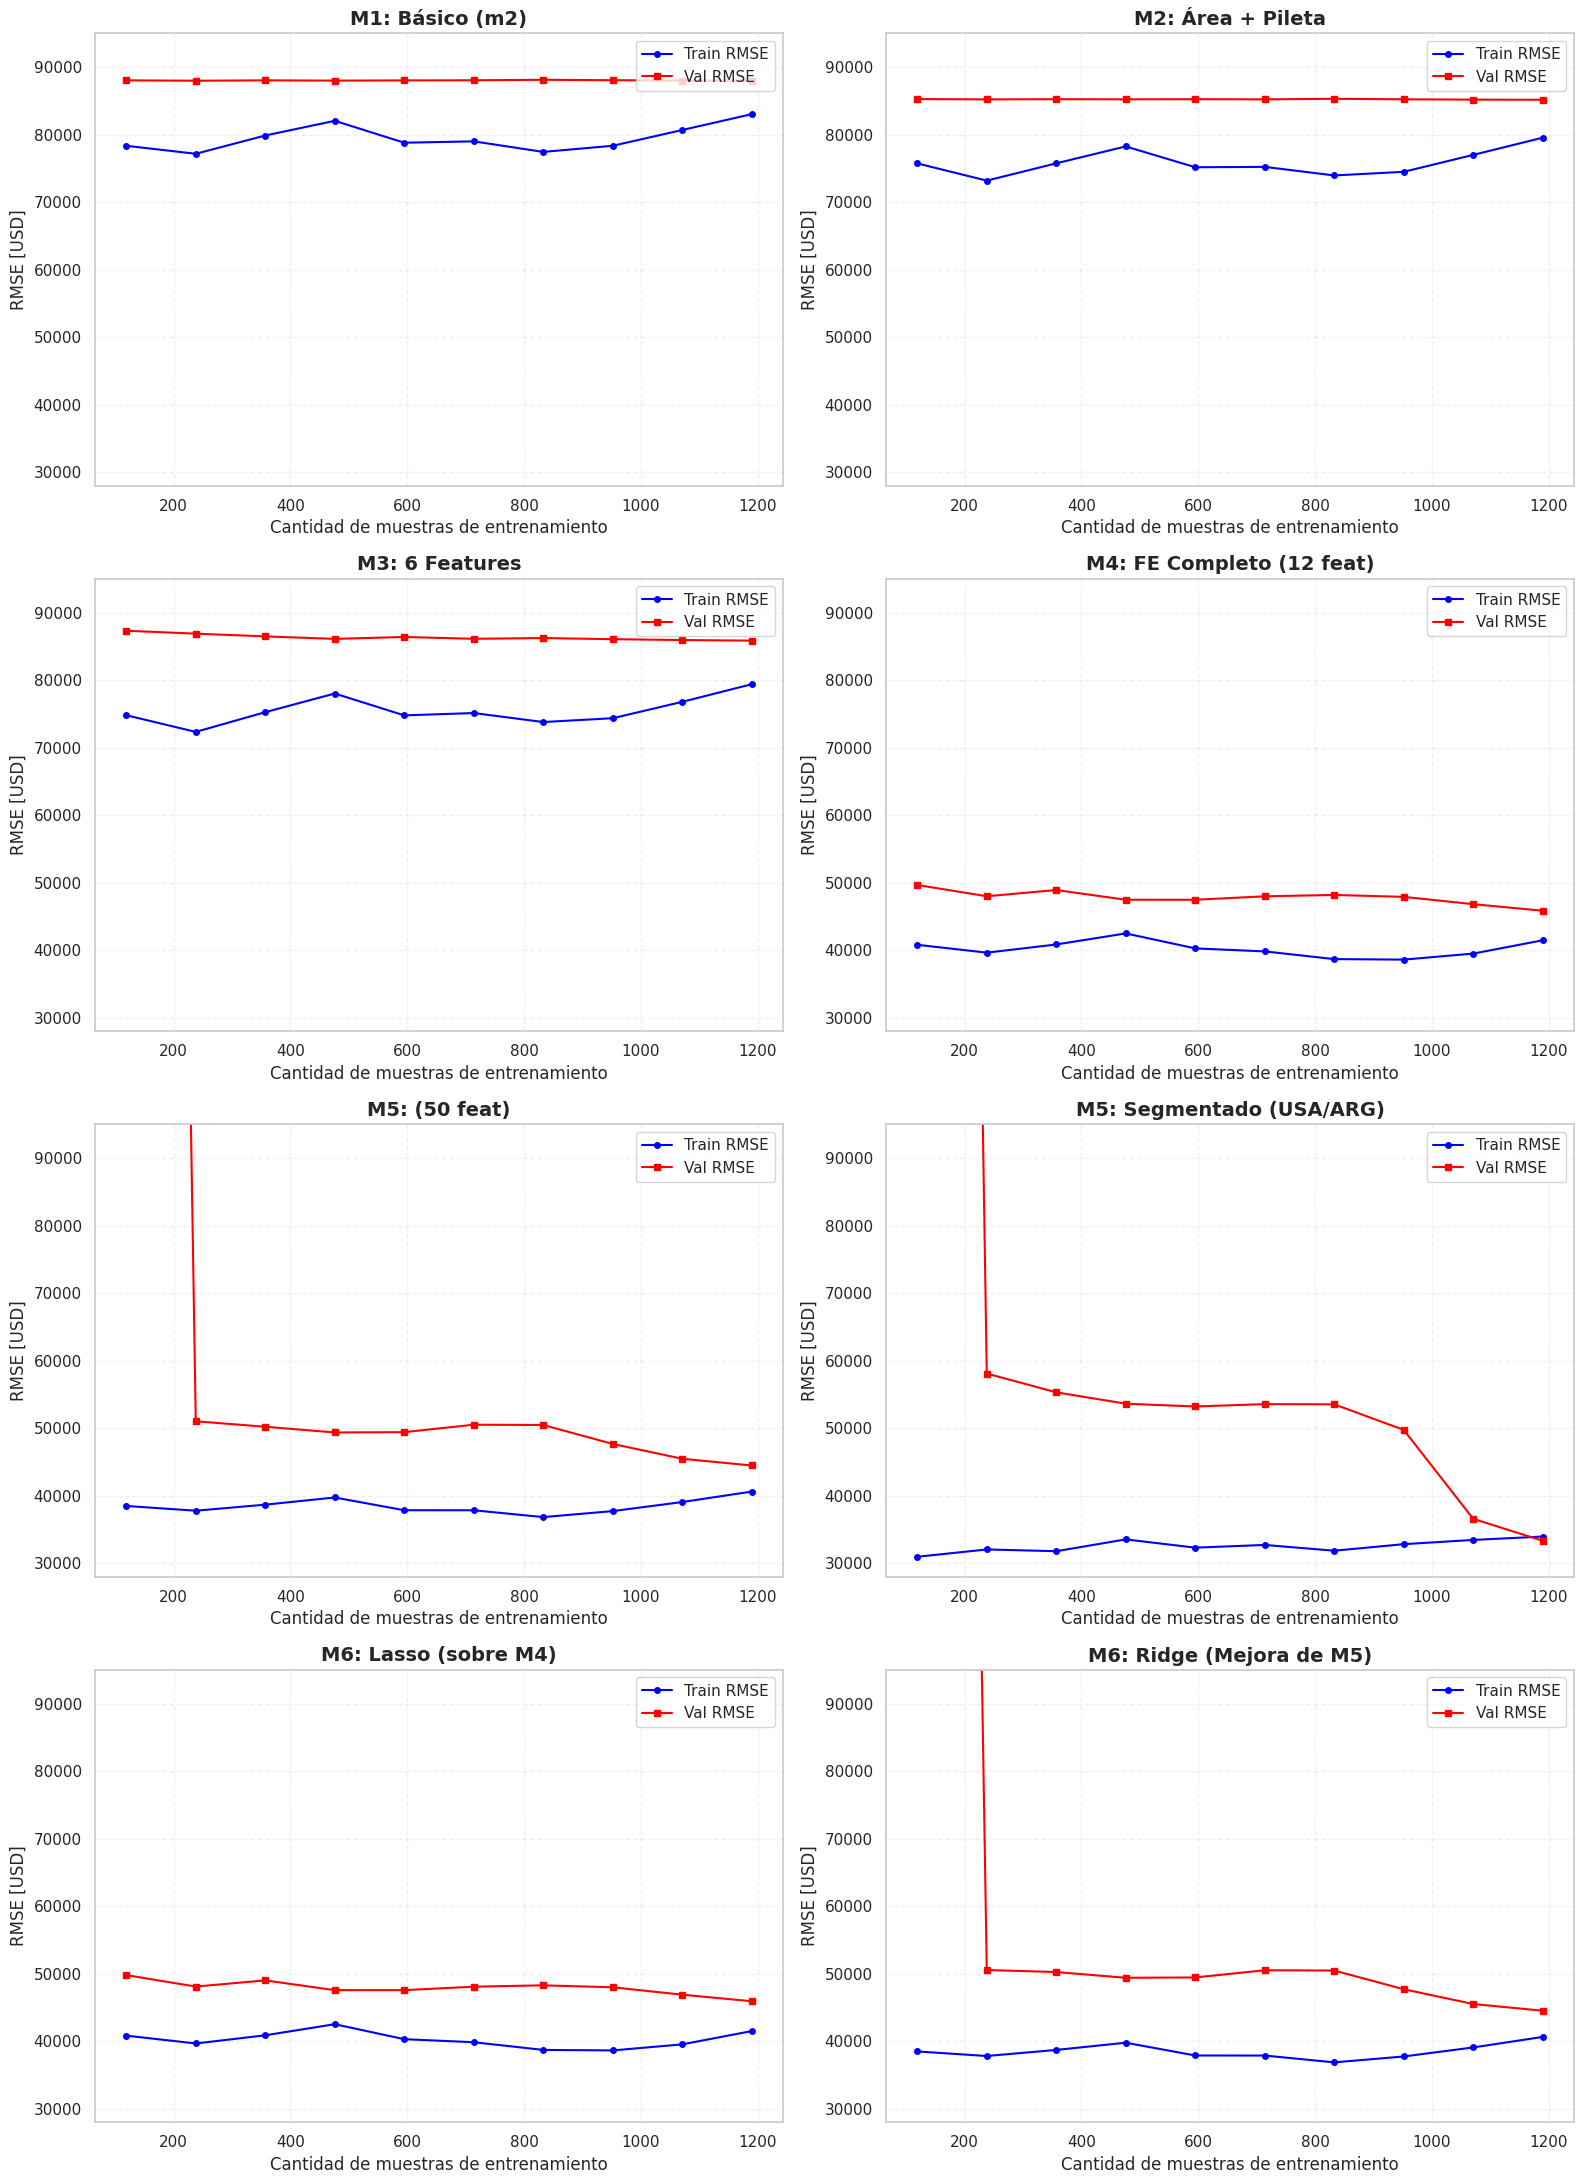

In [60]:

df_train_proc = pd.read_csv("../data/processed/df_train_processed.csv")
df_val_proc = pd.read_csv("../data/processed/df_val_processed.csv")

df_train_m4 = pd.read_csv("../data/processed/train_m4_engineered.csv")
df_val_m4 = pd.read_csv("../data/processed/val_m4_engineered.csv")

features_m1 = ['metros_cubiertos']
features_m2 = ['Área', 'pileta']
features_m3 = ['metros_cubiertos', 'ambientes', 'pileta', 'edad', 'tipo_depto', 'tipo_ph']
features_m4 = [
    'metros_cubiertos', 'ambientes', 'pisos', 'pileta', 'edad', 'tipo_depto', 'tipo_ph',
    'metros_cubiertos_2', 'log_m2', 'interact_m2_usa', 'coef_zona', 'precio_estimado_cuadratico',
]


m_m1, t_m1, v_m1 = get_learning_curve(df_train_proc, df_val_proc, features_m1)

m_m2, t_m2, v_m2 = get_learning_curve(df_train_proc, df_val_proc, features_m2)

m_m3, t_m3, v_m3 = get_learning_curve(df_train_proc, df_val_proc, features_m3)

m_m4, t_m4, v_m4 = get_learning_curve(df_train_m4, df_val_m4, features_m4)

df_train_m5 = df_train_m4.copy()
df_val_m5 = df_val_m4.copy()

df_train_m5, full_features = expand_features(df_train_m5, features_m5)
df_val_m5, _ = expand_features(df_val_m5, list(features_m4))

m_m5, t_m5, v_m5 = get_learning_curve(df_train_m5, df_val_m5, features_m5_final)

# M6 con respecto a M4 y con lasso
m_m6, t_m6, v_m6 = get_learning_curve(df_train_m4, df_val_m4, features_m4, l1=best_lambda_lasso)


# M6 con respecto a M5 y con ridge
m_m6_ridge, t_m6_ridge, v_m6_ridge = get_learning_curve(
    df_train_m5, df_val_m5, features_m5_final, l2=best_lambda_m6_ridge
)

# M5 segmentado por región
m_m5_seg, t_m5_seg, v_m5_seg = get_learning_curve_segmented(
    df_train_m5, df_val_m5, features_m5_final
)


fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

modelos = [
    (m_m1, t_m1, v_m1, "M1: Básico (m2)"),
    (m_m2, t_m2, v_m2, "M2: Área + Pileta"),
    (m_m3, t_m3, v_m3, "M3: 6 Features"),
    (m_m4, t_m4, v_m4, "M4: FE Completo (12 feat)"),
    (m_m5, t_m5, v_m5, "M5: (50 feat)"),
    (m_m5_seg, t_m5_seg, v_m5_seg, "M5: Segmentado (USA/ARG)"),
    (m_m6, t_m6, v_m6, "M6: Lasso (sobre M4)"),
    (m_m6_ridge, t_m6_ridge, v_m6_ridge, "M6: Ridge (Mejora de M5)"),
]

for i, (m, t, v, title) in enumerate(modelos):
    axes[i].plot(m, t, label='Train RMSE', color='blue', marker='o', markersize=4)
    axes[i].plot(m, v, label='Val RMSE', color='red', marker='s', markersize=4)

    axes[i].set_title(title, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Cantidad de muestras de entrenamiento')
    axes[i].set_ylabel('RMSE [USD]')
    axes[i].legend(loc='upper right')
    axes[i].grid(alpha=0.3, linestyle='--')
    axes[i].set_ylim(28000, 95000)

plt.tight_layout()
plt.show()

#### Explicación de resultados

Primeramente, en los modelos iniciales (M1, M2 y M3), se observa un escenario de alto sesgo (underfitting): tanto el error de entrenamiento como el de validación se estabilizan rápidamente en valores muy elevados (en torno a los 80,000–87,000 USD), indicando que la arquitectura de estos modelos es demasiado simple para capturar la estructura subyacente de los datos. A partir del modelo M4, la introducción del feature engineering y de la información geográfica permite una reducción drástica del RMSE, situando la convergencia en torno a los 41,000–45,000 USD y logrando curvas mucho más próximas entre sí.

Luego, en los modelos M5 y M6 el error de validación comienza alto en muestras pequeñas debido a la falta de representatividad estadística, pero converge rápidamente hacia el error de entrenamiento a medida que la cantidad de muestras aumenta. Un hallazgo consistente con lo visto en la sección 5 es la casi nula diferencia entre las curvas de M4 y M5 y las de sus variantes regularizadas (M6): las trayectorias de convergencia son prácticamente idénticas. La brecha pequeña y estable entre train y validación explica por qué: no hay una varianza excesiva que la regularización pueda recortar.

El verdadero punto de inflexión aparece con el M5 Segmentado (USA/ARG). A diferencia de la regularización, la segmentación geográfica desplaza hacia abajo la convergencia de las curvas, llevando el error global por debajo de los 34,000 USD. Este comportamiento confirma que la limitación de los modelos globales no era la varianza de los parámetros sino un sesgo estructural: un único hiperplano no puede describir dos mercados con dinámicas distintas, y especializar el modelo por región reduce ese sesgo de una forma que ni el agregado de features (M5) ni la penalización de coeficientes (M6) podían lograr. Cabe aclarar que la comparación entre segmentar y regularizar se completó en la sección 5.4, donde se aplicó regularización sobre el propio modelo segmentado y se verificó que tampoco allí aporta mejoras.

### 6.2 Selección de modelo para producción

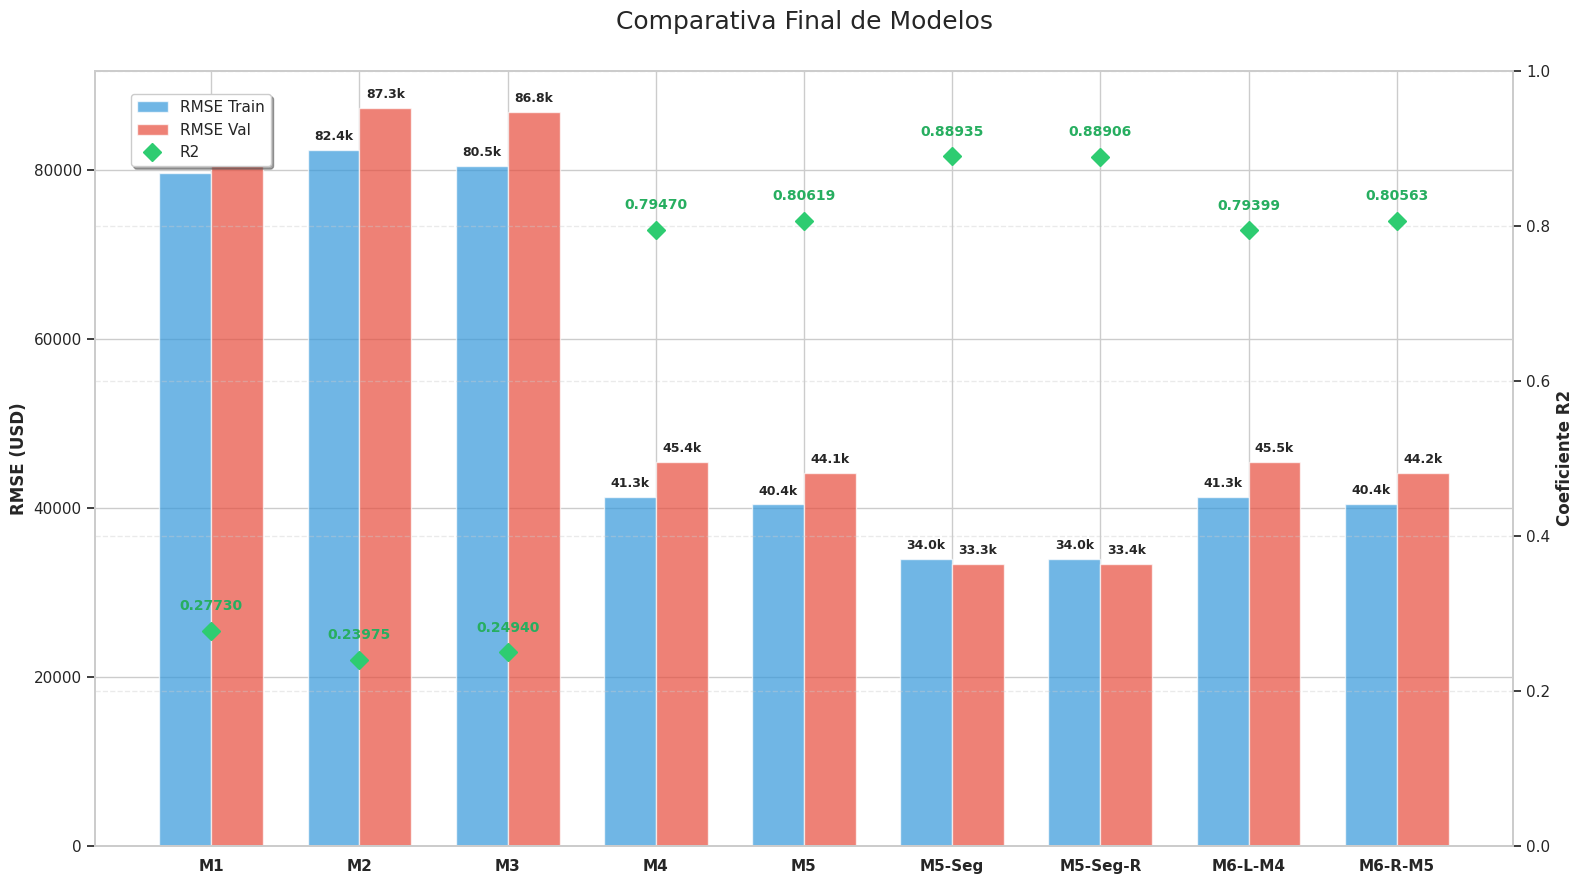

In [61]:
from src.metrics import r2

y_train_total_raw = np.vstack((res_usa[5], res_arg[5]))
y_train_total_pred = np.vstack((res_usa[6], res_arg[6]))

y_val_total_raw = np.vstack((res_usa[7], res_arg[7]))
y_val_total_pred = np.vstack((res_usa[8], res_arg[8]))

resultados = {
    'M1': {'t': rmse(y_train_usd, y_train_pred_m1_usd), 'v': rmse(y_val_usd, y_val_pred_m1_usd), 'r2': r2(y_val_usd, y_val_pred_m1_usd)},
    'M2': {'t': rmse(y_train_usd, y_train_pred_m2), 'v': rmse(y_val_usd, y_val_pred_m2), 'r2': r2(y_val_usd, y_val_pred_m2)},
    'M3': {'t': rmse(y_train_usd, y_train_pred_m3_usd), 'v': rmse(y_val_usd, y_val_pred_m3_usd), 'r2': r2(y_val_usd, y_val_pred_m3_usd)},
    'M4': {'t': rmse(y_train_usd, y_train_pred_m4), 'v': rmse(y_val_usd, y_val_pred_m4), 'r2': r2(y_val_usd, y_val_pred_m4)},
    'M5': {'t': rmse(y_train_usd, y_train_pred_m5), 'v': rmse(y_val_usd, y_val_pred_m5), 'r2': r2(y_val_usd, y_val_pred_m5)},
    'M5-Seg': {'t': rmse(y_train_total_raw, y_train_total_pred), 'v': rmse(y_val_total_raw, y_val_total_pred), 'r2': r2(y_val_total_raw, y_val_total_pred)},
    'M5-Seg-R': {'t': rmse(y_train_seg_ridge_raw, y_train_seg_ridge_pred), 'v': rmse(y_val_seg_ridge_raw, y_val_seg_ridge_pred), 'r2': r2(y_val_seg_ridge_raw, y_val_seg_ridge_pred)},
    'M6-L-M4': {'t': rmse_l_train, 'v': rmse_l_val, 'r2': r2(y_val_raw, res_lasso_val)},
    'M6-R-M5': {'t': rmse(y_train_usd, y_train_pred_m6), 'v': rmse(y_val_usd, y_val_pred_m6), 'r2': r2(y_val_usd, y_val_pred_m6)},
}

labels = list(resultados.keys())
train_vals = [v['t'] for v in resultados.values()]
val_vals = [v['v'] for v in resultados.values()]
r2_vals = [v['r2'] for v in resultados.values()]

x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(16, 9))

rects1 = ax1.bar(x - width/2, train_vals, width, label='RMSE Train', color='#3498db', alpha=0.7)
rects2 = ax1.bar(x + width/2, val_vals, width, label='RMSE Val', color='#e74c3c', alpha=0.7)

ax2 = ax1.twinx()
# Los modelos no guardan relación secuencial entre sí: se grafican solo los markers, sin unirlos
ax2.plot(x, r2_vals, color='#2ecc71', marker='D', markersize=9, linestyle='none', label='R2')

ax1.set_ylabel('RMSE (USD)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Coeficiente R2', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.0) 
ax1.set_title('Comparativa Final de Modelos', fontsize=18, pad=30)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11, fontweight='bold')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax1.annotate(f'{height/1000:.1f}k', 
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points", 
                    ha='center', va='bottom', 
                    fontsize=9, fontweight='bold',
                    rotation=0)

autolabel(rects1)
autolabel(rects2)

for i, txt in enumerate(r2_vals):
    ax2.annotate(f'{txt:.5f}', (x[i], r2_vals[i]), 
                 xytext=(0, 15), 
                 textcoords="offset points", 
                 ha='center', color='#27ae60', 
                 fontweight='bold', fontsize=10)

lines, labels_lines = ax1.get_legend_handles_labels()
lines2, labels_lines2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels_lines + labels_lines2, 
           loc='upper left', bbox_to_anchor=(0.02, 0.98), frameon=True, shadow=True)

plt.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)
plt.tight_layout()

plt.show()

In [62]:
print("Modelo | RMSE Train (USD) | RMSE Val (USD) | R2")

for nombre, metrica in resultados.items():
    t_rmse = metrica['t']
    v_rmse = metrica['v']
    r2_val = metrica['r2']
    
    print(f"{nombre} | {t_rmse:.2f} | {v_rmse:.2f} | {r2_val:6f}")

Modelo | RMSE Train (USD) | RMSE Val (USD) | R2
M1 | 79605.65 | 85164.94 | 0.277302
M2 | 82374.79 | 87349.71 | 0.239748
M3 | 80456.89 | 86793.49 | 0.249399
M4 | 41306.24 | 45392.10 | 0.794697
M5 | 40384.85 | 44102.92 | 0.806193
M5-Seg | 33950.75 | 33323.58 | 0.889353
M5-Seg-R | 33966.05 | 33368.33 | 0.889056
M6-L-M4 | 41325.86 | 45470.22 | 0.793990
M6-R-M5 | 40412.54 | 44166.97 | 0.805630


Tras analizar en detalle todas las arquitecturas propuestas, se selecciona el modelo **M5 Segmentado (M5-Seg)** como la mejor opción para implementar en producción. Esta decisión se basa principalmente en su desempeño superior, ya que alcanza el menor error de validación (RMSE = 33,323.58 USD) y el mayor poder explicativo ($R^2 = 0.8894$), mejorando con claridad al mejor modelo global (M5, con 44,102.92 USD). Esta mejora evidencia que separar el problema por mercado (Argentina y Estados Unidos) resulta mucho más efectivo que seguir aumentando la complejidad de un único modelo global.

Respecto de la regularización, la comparación completa de la sección 5 muestra que no aporta mejoras en este problema: ni sobre los modelos globales (las dos variantes de M6 quedan al nivel de M4 y M5) ni sobre el propio modelo segmentado (M5-Seg-R queda levemente por detrás de M5-Seg). Es importante notar que esta última comparación es la que permite afirmarlo con propiedad: como segmentar y regularizar atacan problemas distintos (sesgo estructural y varianza, respectivamente), la utilidad de la regularización debía evaluarse una vez resuelta la segmentación, y aun así no produjo ganancias. En este sentido, M5-Seg demuestra que adaptar el modelo a la naturaleza de los datos es más efectivo que penalizar sus coeficientes: el problema de este dataset era de sesgo, no de sobreajuste.

### 6.3 MAE y RMSE sobre el conjunto de prueba del modelo seleccionado

In [63]:
import pandas as pd
import numpy as np
from src.metrics import mae, r2, rmse
from src.utils import predict_segment

df_test_raw = pd.read_csv("../data/raw/casas_test.csv")
df_test_clean, _ = preprocess_data(df_test_raw, stats=imput_stats)
df_test_processed, _ = refine_features(df_test_clean, cats_tipo=cats_tipo)
df_test_fe, _ = apply_feature_engineering(df_test_processed, medians_dict=medians_train)
df_test_m5, _ = expand_features(df_test_fe, list(features_m4))

df_test_usa = df_test_m5[df_test_m5['is_usa'] == 1].copy()
df_test_arg = df_test_m5[df_test_m5['is_usa'] == 0].copy()


y_test_usa_raw, y_test_usa_pred = predict_segment(df_test_usa, res_usa[0], features_m5_final, res_usa[1], res_usa[2], res_usa[3], res_usa[4])
y_test_arg_raw, y_test_arg_pred = predict_segment(df_test_arg, res_arg[0], features_m5_final, res_arg[1], res_arg[2], res_arg[3], res_arg[4])

y_test_total_raw = np.vstack((y_test_usa_raw, y_test_arg_raw))
y_test_total_pred = np.vstack((y_test_usa_pred, y_test_arg_pred))

test_rmse_seg = rmse(y_test_total_raw, y_test_total_pred)
test_mae_seg = mae(y_test_total_raw, y_test_total_pred)
test_r2_seg = r2(y_test_total_raw, y_test_total_pred)

val_rmse_m5_seg = resultados['M5-Seg']['v']

print("Evaluación final con m5 segmentado (USA vs ARG)")
print(f"RMSE: {test_rmse_seg:.2f} USD")
print(f"MAE: {test_mae_seg:.2f} USD")
print(f"R2: {test_r2_seg:.6f}")
print(f"RMSE Validación: {val_rmse_m5_seg:.2f} USD")
print(f"Diferencia (Test vs Val): {abs(test_rmse_seg - val_rmse_m5_seg):.2f} USD")

Evaluación final con m5 segmentado (USA vs ARG)
RMSE: 32382.62 USD
MAE: 21443.93 USD
R2: 0.875507
RMSE Validación: 33323.58 USD
Diferencia (Test vs Val): 940.96 USD


La evaluación del modelo M5 Segmentado sobre el conjunto de prueba muestra resultados sólidos, con un RMSE de 32,382.62 USD y un $R^2$ de 0.8755. Estas métricas confirman que el modelo generaliza bien frente a datos no vistos y refuerzan que la segmentación por país fue una decisión clave para mejorar la precisión.

La diferencia entre el error de validación y el de test es de apenas 941 USD (el error de test resultó incluso levemente menor que el de validación), lo que indica que la estimación de desempeño obtenida durante el desarrollo es confiable y que el modelo no presenta señales de overfitting, a pesar de trabajar con un conjunto amplio de variables. A esta estabilidad contribuyen dos decisiones metodológicas tomadas a lo largo del trabajo: la división estratificada (que garantiza conjuntos de entrenamiento y validación comparables por construcción) y el cálculo de todos los estadísticos de preprocesamiento exclusivamente sobre entrenamiento, evitando fugas de información que inflarían artificialmente las métricas.

Por último, el MAE de 21,443.93 USD representa el error promedio de las predicciones: en promedio, el modelo se equivoca en ese monto al estimar el precio de una propiedad. Considerando que el rango de precios del dataset supera los 700,000 USD y que conviven dos mercados con escalas muy distintas, este nivel de error refleja un buen desempeño.